# Human Pose Detection / Keypoint Estimation using MMVR Dataset
**CSE 486/586 Group Project — Spring 2026**

Miami University, Oxford, OH

---

## Overview
This notebook implements a full pipeline for human pose detection using the MMVR
(Millimeter-wave Multi-View Radar) dataset. The pipeline includes:

1. **Data Loading & Preprocessing** — Load RGB frames and mmWave radar heatmaps from the MMVR P1 dataset.
2. **RGB-Based Pose Detection** — Fine-tune a ViTPose / HRNet model on MMVR RGB frames.
3. **Radar-Visual Fusion** — Fuse mmWave horizontal + vertical heatmaps with RGB visual features.
4. **Custom CNN Encoder-Decoder** — Residual + attention-based backbone with Soft-Argmax output.
5. **3D Pose Reconstruction** — Lift 2D keypoints to 3D using radar depth cues.
6. **Evaluation** — PCK, OKS, MAE, F1-Score, Precision under normal and adverse conditions.
7. **Baseline Comparison** — ResNet-18 vs Custom CNN vs Fusion Model.
8. **Visualization** — Skeleton overlays, heatmaps, loss curves, and metric plots.

**Dataset:** MMVR — https://zenodo.org/records/12611978  
**Dataset folder expected at:** `./P1/` (extracted from P1.zip)


---
## 0. Install & Import Dependencies

In [1]:
# ── Install any missing packages (run once) ─────────────────────────────────
import subprocess, sys
def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('opencv-python-headless', 'tqdm', 'scikit-learn', 'seaborn')
try:
    import timm
except ImportError:
    pip_install('timm')
print('All packages installed.')

import os
import json
import glob
import random
import math
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.models import resnet18, ResNet18_Weights

# Optional: timm for ViTPose / HRNet backbone
try:
    import timm
    TIMM_AVAILABLE = True
    print(f"timm version: {timm.__version__}")
except ImportError:
    TIMM_AVAILABLE = False
    print("timm not installed — ViTPose backbone will be skipped; Custom CNN will be used.")

from sklearn.metrics import f1_score, precision_score

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

C:\ProgramData\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All packages installed.
timm version: 1.0.26

Using device: cuda
PyTorch version: 2.12.0.dev20260402+cu128
CUDA available: True


In [2]:
# ── Device diagnostic — run this to confirm CUDA is active ─────────────────
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("WARNING: Running on CPU — training will be extremely slow.")
    print("If you have a GPU, ensure the correct CUDA-enabled PyTorch is installed:")
    print("  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121")
print(f"\nDEVICE = {DEVICE}")


PyTorch version : 2.12.0.dev20260402+cu128
CUDA available  : True
GPU             : NVIDIA GeForce RTX 5070 Ti
VRAM            : 15.9 GB

DEVICE = cuda


---
## 1. Configuration

In [3]:
# ════════════════════════════════════════════════════════════════════
#  CONFIGURATION
# ════════════════════════════════════════════════════════════════════

class Config:
    # ── Paths ────────────────────────────────────────────────────────
    DATA_ROOT       = './P1'             # extracted P1.zip root folder
    SPLIT_FILE      = './data_split.npz' # official MMVR train/val/test split
    CHECKPOINT_DIR  = './checkpoints'
    RESULTS_DIR     = './results'

    # ── Which protocol + split to use (from data_split.npz) ─────────
    # P1S1: single subject, random split         (recommended for this project)
    # P1S2: single subject, cross-environment split
    # P2S1: multiple subjects, random split
    # P2S2: multiple subjects, cross-environment split
    PROTOCOL        = 'P1S1'

    # ── Real image dimensions from MMVR dataset ──────────────────────
    IMG_H           = 480            # actual camera image height
    IMG_W           = 640            # actual camera image width

    # ── Radar heatmap dimensions (from README) ────────────────────────
    RADAR_H         = 256
    RADAR_W         = 128
    HEATMAP_SIZE    = 64             # output heatmap spatial resolution for model
    SIGMA           = 3              # Gaussian sigma for GT heatmap generation

    # ── Keypoints ────────────────────────────────────────────────────
    NUM_KEYPOINTS   = 17
    KP_NAMES = [
        'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
        'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
        'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
        'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
    ]
    SKELETON = [
        (13,15),(11,13),(14,16),(12,14),(11,12),
        (5,11),(6,12),(5,6),(5,7),(6,8),(7,9),
        (8,10),(1,2),(0,1),(0,2),(1,3),(2,4),
        (3,5),(4,6)
    ]

    # ── Training ─────────────────────────────────────────────────────
    BATCH_SIZE      = 32   # increased: larger batches keep GPU busier per disk read
    NUM_EPOCHS      = 30
    LR              = 1e-4   # lowered from 1e-3 — reduces exploding gradients
    LR_STEP         = [15, 25]
    LR_GAMMA        = 0.1
    WEIGHT_DECAY    = 1e-4
    NUM_WORKERS     = 0   # 0 required on Windows to avoid DataLoader deadlock

    # ── Evaluation ───────────────────────────────────────────────────
    PCK_THRESHOLD   = 0.05
    OKS_SIGMAS      = np.array([
        .026,.025,.025,.035,.035,
        .079,.079,.072,.072,.062,
        .062,.107,.107,.087,.087,
        .089,.089
    ])

cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.RESULTS_DIR,    exist_ok=True)
print("Configuration loaded.")
print(f"  Data root    : {cfg.DATA_ROOT}")
print(f"  Split file   : {cfg.SPLIT_FILE}")
print(f"  Protocol     : {cfg.PROTOCOL}")
print(f"  Image size   : {cfg.IMG_H} x {cfg.IMG_W}")
print(f"  Radar shape  : {cfg.RADAR_H} x {cfg.RADAR_W}")


Configuration loaded.
  Data root    : ./P1
  Split file   : ./data_split.npz
  Protocol     : P1S1
  Image size   : 480 x 640
  Radar shape  : 256 x 128


---
## 2. Data Loading & Preprocessing

### 2.1 Explore Dataset Structure

The MMVR P1 folder contains per-sequence subdirectories.  
Each sequence has:
- `rgb/` — RGB frames (`.jpg` or `.png`)
- `hori/` — horizontal mmWave radar heatmaps (`.npy`)
- `vert/` — vertical mmWave radar heatmaps (`.npy`)
- `annotations.json` — COCO-style keypoints & bboxes

In [4]:
def explore_dataset(data_root):
    """
    Walk the P1 directory and print its real structure.
    Expected layout:
        P1/
          d1s1/000/00000_radar.npz  ...
          d1s2/000/00000_pose.npz   ...
    """
    if not os.path.exists(data_root):
        print(f"[WARNING] Data root '{data_root}' not found.")
        print("Please extract P1.zip into the same folder as this notebook.")
        return []

    print(f"Dataset root: {os.path.abspath(data_root)}")
    sessions = sorted([d for d in os.listdir(data_root)
                       if os.path.isdir(os.path.join(data_root, d))])
    print(f"Sessions found: {len(sessions)}  →  {sessions[:6]} ...")

    # Drill into first session to show segment/frame structure
    for sess in sessions[:2]:
        sess_path = os.path.join(data_root, sess)
        segments  = sorted(os.listdir(sess_path))[:2]
        for seg in segments:
            seg_path = os.path.join(sess_path, seg)
            if not os.path.isdir(seg_path): continue
            files = sorted(os.listdir(seg_path))[:5]
            print(f"  {sess}/{seg}/  →  {files}")
    return sessions


In [5]:
# ── STEP 1: Explore the dataset folder structure ───────────────────────────
sequences = explore_dataset(cfg.DATA_ROOT)


Dataset root: C:\Users\andyd\Desktop\MIAMI\GRADUATE\SPRING 2026\CSE586 Introduction to AI\MIDTERM PROJECT\CLAUDE\P1
Sessions found: 7  →  ['d1s1', 'd1s2', 'd2s2', 'd3s1', 'd3s2', 'd4s1'] ...
  d1s1/000/  →  ['00000_bbox.npz', '00000_mask.npz', '00000_meta.npz', '00000_pose.npz', '00000_radar.npz']
  d1s1/001/  →  ['00000_bbox.npz', '00000_mask.npz', '00000_meta.npz', '00000_pose.npz', '00000_radar.npz']
  d1s2/000/  →  ['00000_bbox.npz', '00000_mask.npz', '00000_meta.npz', '00000_pose.npz', '00000_radar.npz']
  d1s2/001/  →  ['00000_bbox.npz', '00000_mask.npz', '00000_meta.npz', '00000_pose.npz', '00000_radar.npz']


### 2.2 Annotation Parser

In [6]:
def load_split_segments(split_file, protocol='P1S1'):
    """
    Load the official MMVR train/val/test segment lists from data_split.npz.

    Each entry in the split lists is a 'session/segment' string,
    e.g. 'd1s1/000', meaning all frames in P1/d1s1/000/ belong to that split.

    Args:
        split_file : path to data_split.npz
        protocol   : one of 'P1S1', 'P1S2', 'P2S1', 'P2S2'

    Returns:
        train_segs, val_segs, test_segs : sets of 'session/segment' strings
    """
    data       = np.load(split_file, allow_pickle=True)
    split_dict = data['data_split_dict'].item()

    if protocol not in split_dict:
        raise ValueError(f"Protocol '{protocol}' not found. "
                         f"Choose from: {list(split_dict.keys())}")

    splits = split_dict[protocol]
    train_segs = set(splits['train'])
    val_segs   = set(splits['val'])
    test_segs  = set(splits['test'])

    print(f"Protocol {protocol} — official segment counts:")
    print(f"  Train : {len(train_segs)} segments")
    print(f"  Val   : {len(val_segs)} segments")
    print(f"  Test  : {len(test_segs)} segments")
    return train_segs, val_segs, test_segs


def load_mmvr_samples_split(data_root, split_file, protocol='P1S1'):
    """
    Scan P1 and assign each person-frame sample to train/val/test
    according to the official data_split.npz segment lists.

    A sample's split is determined by which set its 'session/segment'
    key belongs to (e.g. 'd1s2/007' → whichever split contains that string).

    Returns:
        train_samples, val_samples, test_samples : lists of sample dicts
            Each dict has the same keys as before:
            { radar_path, pose_path, bbox_path, person_idx, session, segment, frame_id }
    """
    if not os.path.exists(data_root):
        print(f"[WARNING] '{data_root}' not found.")
        return [], [], []
    if not os.path.exists(split_file):
        print(f"[WARNING] '{split_file}' not found — place data_split.npz "
              f"in the same folder as this notebook.")
        return [], [], []

    train_segs, val_segs, test_segs = load_split_segments(split_file, protocol)

    train_samples, val_samples, test_samples = [], [], []
    n_skipped = 0

    sessions = sorted([d for d in os.listdir(data_root)
                       if os.path.isdir(os.path.join(data_root, d))])

    for session in tqdm(sessions, desc='Scanning sessions'):
        sess_path = os.path.join(data_root, session)
        segments  = sorted([s for s in os.listdir(sess_path)
                             if os.path.isdir(os.path.join(sess_path, s))])

        for segment in segments:
            seg_key  = f"{session}/{segment}"   # e.g. 'd1s2/007'
            seg_path = os.path.join(sess_path, segment)

            # Determine which split this segment belongs to
            if seg_key in train_segs:
                target = train_samples
            elif seg_key in val_segs:
                target = val_samples
            elif seg_key in test_segs:
                target = test_samples
            else:
                # Segment not listed in the chosen protocol — skip it
                n_skipped += 1
                continue

            # Collect all frames in this segment
            pose_files = sorted(glob.glob(os.path.join(seg_path, '*_pose.npz')))
            for pose_path in pose_files:
                frame_id   = os.path.basename(pose_path).replace('_pose.npz', '')
                radar_path = pose_path.replace('_pose.npz', '_radar.npz')
                bbox_path  = pose_path.replace('_pose.npz', '_bbox.npz')

                if not os.path.exists(radar_path):
                    continue

                try:
                    kp = np.load(pose_path)['kp']   # (n, 17, 3)
                    n_persons = kp.shape[0]
                except Exception:
                    continue

                if n_persons == 0:
                    continue

                for person_idx in range(n_persons):
                    target.append({
                        'radar_path' : radar_path,
                        'pose_path'  : pose_path,
                        'bbox_path'  : bbox_path,
                        'person_idx' : person_idx,
                        'session'    : session,
                        'segment'    : segment,
                        'frame_id'   : frame_id,
                    })

    print(f"\nOfficial split loaded ({protocol}):")
    print(f"  Train : {len(train_samples):,} person-frame samples")
    print(f"  Val   : {len(val_samples):,} person-frame samples")
    print(f"  Test  : {len(test_samples):,} person-frame samples")
    if n_skipped:
        print(f"  Skipped {n_skipped} segments not in protocol '{protocol}'")

    return train_samples, val_samples, test_samples


In [7]:
# ── STEP 2: Load sample paths using the official data_split.npz ─────────────
# Segments are assigned to train/val/test exactly as defined in the split file,
# NOT by random shuffling. This ensures reproducible, officially-sanctioned splits.

train_samples, val_samples, test_samples = load_mmvr_samples_split(
    cfg.DATA_ROOT, cfg.SPLIT_FILE, protocol=cfg.PROTOCOL
)

# Combine for any code that still needs all_samples (e.g. exploration)
all_samples = train_samples + val_samples + test_samples
print(f"\nTotal samples across all splits: {len(all_samples):,}")

if all_samples:
    s = all_samples[0]
    print(f"\nExample sample: session={s['session']}, segment={s['segment']}, "
          f"frame={s['frame_id']}, person_idx={s['person_idx']}")
    pose_data  = np.load(s['pose_path'])
    radar_data = np.load(s['radar_path'])
    print(f"  kp shape      : {pose_data['kp'].shape}   → (n_persons, 17, 3)")
    print(f"  hm_hori shape : {radar_data['hm_hori'].shape}  → (256, 128)")
    print(f"  hm_vert shape : {radar_data['hm_vert'].shape}  → (256, 128)")


Protocol P1S1 — official segment counts:
  Train : 98 segments
  Val   : 12 segments
  Test  : 12 segments


Scanning sessions: 100%|██████████| 7/7 [06:35<00:00, 56.53s/it] 


Official split loaded (P1S1):
  Train : 86,579 person-frame samples
  Val   : 10,538 person-frame samples
  Test  : 10,785 person-frame samples

Total samples across all splits: 107,902

Example sample: session=d1s1, segment=000, frame=00000, person_idx=0
  kp shape      : (1, 17, 3)   → (n_persons, 17, 3)
  hm_hori shape : (256, 128)  → (256, 128)
  hm_vert shape : (256, 128)  → (256, 128)


### 2.3 Gaussian Heatmap Generator

In [8]:
def generate_gaussian_heatmap(heatmap_size, keypoints, sigma=2):
    """
    Generate 2D Gaussian heatmaps for ground-truth keypoints.

    keypoints: (17, 3) — [x=col, y=row, visibility] in absolute image pixels
    Returns:   (17, H, W) float32 heatmaps
    """
    H = W = heatmap_size
    heatmaps = np.zeros((17, H, W), dtype=np.float32)

    for k, (x, y, v) in enumerate(keypoints):
        if v < 0.1:          # skip low-confidence keypoints
            continue
        # x=col → maps to heatmap width axis
        # y=row → maps to heatmap height axis
        cx = int(x / cfg.IMG_W * W)
        cy = int(y / cfg.IMG_H * H)
        cx = np.clip(cx, 0, W-1)
        cy = np.clip(cy, 0, H-1)

        xs = np.arange(W)
        ys = np.arange(H)
        xx, yy = np.meshgrid(xs, ys)
        g = np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))
        heatmaps[k] = np.maximum(heatmaps[k], g)

    return heatmaps

print("generate_gaussian_heatmap defined.")


generate_gaussian_heatmap defined.


### 2.4 MMVR Dataset Class

In [9]:
class MMVRDataset(Dataset):
    """
    PyTorch Dataset for the MMVR P1 dataset.
    Loads radar heatmaps and keypoints directly from .npz files.
    """

    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def _load_radar(self, radar_path):
        """
        Load and sanitise hm_hori + hm_vert from _radar.npz.
        Replaces any nan/inf values with 0 before normalising.
        Returns Tensor (2, RADAR_H, RADAR_W).
        """
        data = np.load(radar_path)
        hori = data['hm_hori'].astype(np.float32)
        vert = data['hm_vert'].astype(np.float32)

        for arr in [hori, vert]:
            # Replace nan and inf with 0 before doing anything else
            np.nan_to_num(arr, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            # Normalise to [0, 1]
            mn, mx = arr.min(), arr.max()
            if mx > mn:
                arr[:] = (arr - mn) / (mx - mn)

        if hori.shape != (cfg.RADAR_H, cfg.RADAR_W):
            hori = cv2.resize(hori, (cfg.RADAR_W, cfg.RADAR_H),
                              interpolation=cv2.INTER_LINEAR)
            vert = cv2.resize(vert, (cfg.RADAR_W, cfg.RADAR_H),
                              interpolation=cv2.INTER_LINEAR)

        return torch.from_numpy(np.stack([hori, vert], axis=0))

    def _load_keypoints(self, pose_path, person_idx):
        """
        Load keypoints for one person from _pose.npz.
        Returns kp_norm (17,2) normalised to [0,1] and vis (17,).
        """
        data = np.load(pose_path)
        kp   = data['kp'][person_idx]       # (17, 3)
        x, y, vis = kp[:,0], kp[:,1], kp[:,2]
        # x = col (width axis), y = row (height axis)
        x_norm = np.clip(x / cfg.IMG_W, 0.0, 1.0).astype(np.float32)
        y_norm = np.clip(y / cfg.IMG_H, 0.0, 1.0).astype(np.float32)
        kp_norm = np.stack([x_norm, y_norm], axis=1)  # (17,2): [col_norm, row_norm]
        # Sanitise keypoints too
        np.nan_to_num(kp_norm, copy=False, nan=0.0)
        np.nan_to_num(vis,     copy=False, nan=0.0)
        return kp_norm, vis.astype(np.float32)

    def _augment_radar(self, radar):
        if random.random() < 0.5:
            radar = np.flip(radar, axis=2).copy()
        if random.random() < 0.3:
            radar = np.clip(
                radar + np.random.randn(*radar.shape).astype(np.float32)*0.02,
                0, 1)
        if random.random() < 0.3:
            radar = np.clip(radar * random.uniform(0.7, 1.3), 0, 1)
        return radar

    def _augment_keypoints(self, kp_norm, vis):
        FLIP_PAIRS = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]
        kp_norm = kp_norm.copy(); vis = vis.copy()
        if random.random() < 0.5:
            kp_norm[:, 0] = 1.0 - kp_norm[:, 0]
            for l, r in FLIP_PAIRS:
                kp_norm[[l,r]] = kp_norm[[r,l]]
                vis[[l,r]]     = vis[[r,l]]
        if random.random() < 0.3:
            kp_norm = np.clip(
                kp_norm + np.random.randn(*kp_norm.shape).astype(np.float32)*0.01,
                0, 1)
        return kp_norm, vis

    def __getitem__(self, idx):
        s = self.samples[idx]
        radar            = self._load_radar(s['radar_path'])
        kp_norm, vis     = self._load_keypoints(s['pose_path'], s['person_idx'])

        if self.augment:
            radar         = self._augment_radar(radar.numpy())
            radar         = torch.from_numpy(radar)
            kp_norm, vis  = self._augment_keypoints(kp_norm, vis)

        kp_abs      = kp_norm.copy()
        kp_abs[:,0] *= cfg.IMG_W   # x = col → scale by W
        kp_abs[:,1] *= cfg.IMG_H   # y = row → scale by H
        kp_with_vis = np.concatenate([kp_abs, vis[:,None]], axis=1)
        heatmap     = generate_gaussian_heatmap(cfg.HEATMAP_SIZE,
                                                kp_with_vis, sigma=cfg.SIGMA)
        return {
            'radar'   : radar,
            'heatmap' : torch.from_numpy(heatmap),
            'coords'  : torch.from_numpy(kp_norm).float(),
            'vis'     : torch.from_numpy(vis).float(),
            'session' : s['session'],
        }

print("MMVRDataset defined (with nan/inf sanitisation).")


MMVRDataset defined (with nan/inf sanitisation).


### 2.5 Create Train / Val / Test Splits

In [10]:
def create_dataloaders(all_samples, cfg):
    """
    Split samples into train/val/test and return DataLoaders.
    Splits at the sample (person-frame) level after shuffling.
    """
    random.shuffle(all_samples)
    n       = len(all_samples)
    n_train = int(n * cfg.TRAIN_RATIO)
    n_val   = int(n * cfg.VAL_RATIO)

    train_samples = all_samples[:n_train]
    val_samples   = all_samples[n_train : n_train + n_val]
    test_samples  = all_samples[n_train + n_val :]

    train_ds = MMVRDataset(train_samples, augment=True)
    val_ds   = MMVRDataset(val_samples,   augment=False)
    test_ds  = MMVRDataset(test_samples,  augment=False)

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE,
                              shuffle=True,  num_workers=cfg.NUM_WORKERS,
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE,
                              shuffle=False, num_workers=cfg.NUM_WORKERS,
                              pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE,
                              shuffle=False, num_workers=cfg.NUM_WORKERS,
                              pin_memory=True)

    print(f"Train : {len(train_ds):,} samples")
    print(f"Val   : {len(val_ds):,} samples")
    print(f"Test  : {len(test_ds):,} samples")
    return train_loader, val_loader, test_loader


In [11]:
# ── STEP 3: Create DataLoaders from the official split ──────────────────────

def create_dataloaders_from_splits(train_samples, val_samples,
                                   test_samples, cfg):
    train_ds = MMVRDataset(train_samples, augment=True)
    val_ds   = MMVRDataset(val_samples,   augment=False)
    test_ds  = MMVRDataset(test_samples,  augment=False)

    loader_kwargs = dict(
        batch_size  = cfg.BATCH_SIZE,
        num_workers = cfg.NUM_WORKERS,
        pin_memory  = True,
    )
    train_loader = DataLoader(train_ds, shuffle=True,  **loader_kwargs)
    val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kwargs)
    test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kwargs)

    print(f"DataLoaders created:")
    print(f"  Train : {len(train_ds):,} samples  ({len(train_loader)} batches)")
    print(f"  Val   : {len(val_ds):,} samples  ({len(val_loader)} batches)")
    print(f"  Test  : {len(test_ds):,} samples  ({len(test_loader)} batches)")
    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = \
    create_dataloaders_from_splits(train_samples, val_samples, test_samples, cfg)


DataLoaders created:
  Train : 86,579 samples  (2706 batches)
  Val   : 10,538 samples  (330 batches)
  Test  : 10,785 samples  (338 batches)


In [12]:
# ════════════════════════════════════════════════════════════════════
#  PREFETCH LOADER — keeps GPU fed by loading next batch in background
#  Uses a single Python thread (no multiprocessing) so it works on
#  Windows without deadlocks, while still hiding disk I/O latency.
# ════════════════════════════════════════════════════════════════════

import threading
import queue

class PrefetchLoader:
    """
    Wraps any DataLoader and prefetches the next batch onto the GPU
    while the current batch is being processed.

    This hides disk I/O and CPU preprocessing latency behind GPU compute,
    dramatically improving GPU utilisation on slow storage systems.

    Uses a single background thread — no multiprocessing, no deadlocks.

    Usage:
        loader = PrefetchLoader(DataLoader(...), device)
        for batch in loader:
            # batch tensors are already on GPU
            ...
    """

    def __init__(self, loader, device, queue_size=2):
        """
        Args:
            loader     : any PyTorch DataLoader
            device     : torch.device to prefetch tensors onto
            queue_size : number of batches to prefetch ahead (default 2)
        """
        self.loader     = loader
        self.device     = device
        self.queue_size = queue_size

    def __len__(self):
        return len(self.loader)

    def __iter__(self):
        # Queue holds prefetched batches; None signals end of data
        batch_queue = queue.Queue(maxsize=self.queue_size)

        def producer():
            """Background thread: loads batches and pushes to GPU."""
            try:
                for batch in self.loader:
                    # Move all tensors to GPU asynchronously
                    gpu_batch = {}
                    for k, v in batch.items():
                        if isinstance(v, torch.Tensor):
                            # non_blocking=True overlaps H2D transfer with CPU work
                            gpu_batch[k] = v.to(self.device, non_blocking=True)
                        else:
                            gpu_batch[k] = v
                    batch_queue.put(gpu_batch)
            finally:
                batch_queue.put(None)   # sentinel

        thread = threading.Thread(target=producer, daemon=True)
        thread.start()

        while True:
            batch = batch_queue.get()
            if batch is None:
                break
            yield batch

        thread.join()


def wrap_with_prefetch(loader, device):
    """Wrap a DataLoader with PrefetchLoader for GPU prefetching."""
    return PrefetchLoader(loader, device)


print("PrefetchLoader defined.")
print("GPU prefetching will keep the GPU fed while disk I/O happens in background.")


PrefetchLoader defined.
GPU prefetching will keep the GPU fed while disk I/O happens in background.


### 2.6 Visualise Raw Samples

In [13]:
def visualise_sample(sample, mask_path=None):
    """
    4-panel visualisation for one sample.
    coords[:,0] = x = col (width  axis) → matplotlib X (horizontal)
    coords[:,1] = y = row (height axis) → matplotlib Y (vertical)
    """
    hori   = sample['radar'][0].numpy()
    vert   = sample['radar'][1].numpy()
    coords = sample['coords'].numpy()   # (17,2): [x=col_norm, y=row_norm]
    vis    = sample['vis'].numpy()

    canvas = np.zeros((cfg.IMG_H, cfg.IMG_W, 3), dtype=np.uint8)
    has_mask = False
    if mask_path is not None and os.path.exists(mask_path):
        try:
            masks   = np.load(mask_path)['mask']
            colours = [(0,180,0),(0,120,255),(255,80,0),(180,0,180),(0,200,200)]
            for pi in range(masks.shape[0]):
                col = colours[pi % len(colours)]
                for ch, cv in enumerate(col):
                    canvas[:,:,ch][masks[pi]] = cv
            has_mask = True
        except Exception:
            pass

    panel1_title = ('Segmentation mask + keypoints'
                    if has_mask else 'Blank canvas + keypoints')

    def draw_skeleton(ax, coords, vis, kp_colour, bone_colour, label_kps=False):
        # coords[:,0]=x=col → ax horizontal, coords[:,1]=y=row → ax vertical
        for a, b in cfg.SKELETON:
            if vis[a] > 0.1 and vis[b] > 0.1:
                ax.plot(
                    [coords[a,0]*cfg.IMG_W, coords[b,0]*cfg.IMG_W],  # x=col
                    [coords[a,1]*cfg.IMG_H, coords[b,1]*cfg.IMG_H],  # y=row
                    '-', color=bone_colour, lw=1.8, zorder=2
                )
        for ki in range(17):
            if vis[ki] > 0.1:
                px = coords[ki,0] * cfg.IMG_W   # x=col → horizontal
                py = coords[ki,1] * cfg.IMG_H   # y=row → vertical
                ax.plot(px, py, 'o', color=kp_colour, ms=6, zorder=3)
                if label_kps:
                    ax.text(px+4, py-4, cfg.KP_NAMES[ki],
                            fontsize=5, color='white',
                            bbox=dict(boxstyle='round,pad=0.1',
                                      fc='black', alpha=0.4))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(canvas)
    draw_skeleton(axes[0], coords, vis, 'lime', 'cyan', label_kps=True)
    axes[0].set_xlim(0, cfg.IMG_W); axes[0].set_ylim(cfg.IMG_H, 0)
    axes[0].set_title(panel1_title, fontsize=10); axes[0].axis('off')

    axes[1].imshow(np.zeros_like(canvas))
    draw_skeleton(axes[1], coords, vis, 'lime', 'cyan')
    axes[1].set_xlim(0, cfg.IMG_W); axes[1].set_ylim(cfg.IMG_H, 0)
    axes[1].set_title('Keypoint skeleton (GT)', fontsize=10); axes[1].axis('off')

    axes[2].imshow(hori, cmap='plasma', aspect='auto')
    axes[2].set_title('Horizontal radar heatmap', fontsize=10)

    axes[3].imshow(vert, cmap='plasma', aspect='auto')
    axes[3].set_title('Vertical radar heatmap', fontsize=10)

    plt.suptitle(f"Session: {sample.get('session','')}", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.RESULTS_DIR, 'sample_visualisation.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

print("visualise_sample defined.")


visualise_sample defined.


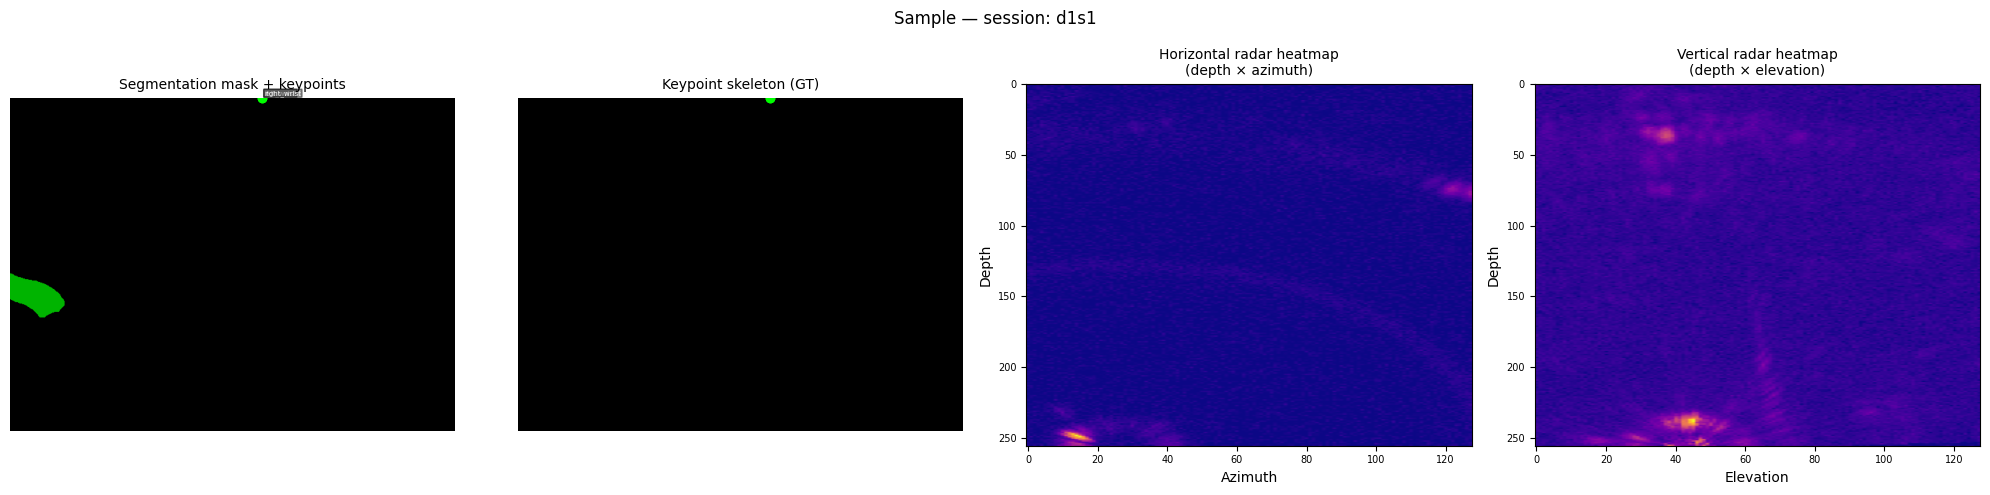


Sample keys & shapes:
  radar     : [2, 256, 128]
  heatmap   : [17, 64, 64]
  coords    : [17, 2]
  vis       : [17]
  session   : d1s1

Mask file: ./P1\d1s1\000\00000_mask.npz
Mask exists: True


In [14]:
# ── STEP 4: Visualise a single raw training sample ──────────────────────────
# Displays: segmentation mask (proxy for the camera view), horizontal radar
# heatmap, vertical radar heatmap, and the 17 keypoints overlaid on the mask.
#
# NOTE: MMVR does not distribute RGB images, but each frame includes a
# per-pixel segmentation mask (n, 480, 640) in _mask.npz that we can use
# as a visual stand-in for the camera image.

def visualise_sample(sample, mask_path=None):
    """
    4-panel visualisation for one sample:
      Panel 1 — Segmentation mask (from _mask.npz) as a proxy camera image,
                 with the 17 keypoints and skeleton overlaid.
      Panel 2 — Keypoints only on a blank canvas (what the model sees as GT).
      Panel 3 — Horizontal mmWave radar heatmap.
      Panel 4 — Vertical mmWave radar heatmap.

    Args:
        sample    : dict returned by MMVRDataset.__getitem__()
        mask_path : path to the corresponding _mask.npz file (optional).
                    If None, Panel 1 falls back to blank canvas.
    """
    hori   = sample['radar'][0].numpy()    # (RADAR_H, RADAR_W)
    vert   = sample['radar'][1].numpy()
    coords = sample['coords'].numpy()      # (17, 2)  [x_norm, y_norm], normalised
    vis    = sample['vis'].numpy()         # (17,)

    # ── Build canvas for Panel 1 ────────────────────────────────────
    canvas = np.zeros((cfg.IMG_H, cfg.IMG_W, 3), dtype=np.uint8)

    if mask_path is not None and os.path.exists(mask_path):
        try:
            mask_data   = np.load(mask_path)
            masks       = mask_data['mask']          # (n_persons, 480, 640) bool
            # Colour each person's mask a different colour
            colours = [(0,180,0), (0,120,255), (255,80,0),
                       (180,0,180), (0,200,200)]
            for pi in range(masks.shape[0]):
                col = colours[pi % len(colours)]
                for ch, cv in enumerate(col):
                    canvas[:, :, ch][masks[pi]] = cv
            has_mask = True
        except Exception:
            has_mask = False
    else:
        has_mask = False

    panel1_title = ('Segmentation mask + keypoints'
                    if has_mask else 'Blank canvas + keypoints\n(mask unavailable)')

    # ── Skeleton drawing helper ──────────────────────────────────────
    def draw_skeleton(ax, coords, vis, kp_colour, bone_colour, label_kps=False):
        for a, b in cfg.SKELETON:
            if vis[a] > 0.1 and vis[b] > 0.1:
                ax.plot(
                    [coords[a,0]*cfg.IMG_W, coords[b,0]*cfg.IMG_W],
                    [coords[a,1]*cfg.IMG_H, coords[b,1]*cfg.IMG_H],
                    '-', color=bone_colour, lw=1.8, zorder=2
                )
        for ki in range(17):
            if vis[ki] > 0.1:
                px = coords[ki,0] * cfg.IMG_W
                py = coords[ki,1] * cfg.IMG_H
                ax.plot(px, py, 'o', color=kp_colour, ms=6, zorder=3)
                if label_kps:
                    ax.text(px+4, py-4, cfg.KP_NAMES[ki],
                            fontsize=5, color='white',
                            bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.4))

    # ── Plot ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Panel 1: mask (or blank) + skeleton
    axes[0].imshow(canvas)
    draw_skeleton(axes[0], coords, vis, kp_colour='lime', bone_colour='cyan',
                  label_kps=True)
    axes[0].set_xlim(0, cfg.IMG_W); axes[0].set_ylim(cfg.IMG_H, 0)
    axes[0].set_title(panel1_title, fontsize=10)
    axes[0].axis('off')

    # Panel 2: blank canvas + skeleton only (what model GT looks like)
    axes[1].imshow(np.zeros_like(canvas))
    draw_skeleton(axes[1], coords, vis, kp_colour='lime', bone_colour='cyan')
    axes[1].set_xlim(0, cfg.IMG_W); axes[1].set_ylim(cfg.IMG_H, 0)
    axes[1].set_title('Keypoint skeleton (GT)', fontsize=10)
    axes[1].axis('off')

    # Panel 3: horizontal radar heatmap
    axes[2].imshow(hori, cmap='plasma', aspect='auto')
    axes[2].set_title('Horizontal radar heatmap\n(depth × azimuth)', fontsize=10)
    axes[2].set_xlabel('Azimuth'); axes[2].set_ylabel('Depth')
    axes[2].tick_params(labelsize=7)

    # Panel 4: vertical radar heatmap
    axes[3].imshow(vert, cmap='plasma', aspect='auto')
    axes[3].set_title('Vertical radar heatmap\n(depth × elevation)', fontsize=10)
    axes[3].set_xlabel('Elevation'); axes[3].set_ylabel('Depth')
    axes[3].tick_params(labelsize=7)

    sess = sample.get('session', '')
    plt.suptitle(f'Sample — session: {sess}', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.RESULTS_DIR, 'sample_visualisation.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


# ── Load sample and find its mask file ──────────────────────────────────────
sample0    = train_ds[0]
sample_meta = train_samples[0]   # has pose_path we can derive mask_path from
mask_path  = sample_meta['pose_path'].replace('_pose.npz', '_mask.npz')

visualise_sample(sample0, mask_path=mask_path)

print(f"\nSample keys & shapes:")
for k, v in sample0.items():
    if hasattr(v, 'shape'):
        print(f"  {k:10s}: {list(v.shape)}")
    else:
        print(f"  {k:10s}: {v}")
print(f"\nMask file: {mask_path}")
print(f"Mask exists: {os.path.exists(mask_path)}")


In [15]:
# ── DIAGNOSTIC: Find a high-quality sample and check axis orientation ────────
# Search through samples to find one with high mean keypoint confidence
best_score = 0
best_sample = None
best_kp = None

print("Searching for a high-confidence sample...")
for s in train_samples[:500]:   # check first 500
    try:
        kp = np.load(s['pose_path'])['kp']
        for pi in range(kp.shape[0]):
            mean_sc = kp[pi, :, 2].mean()
            if mean_sc > best_score:
                best_score = mean_sc
                best_sample = s
                best_kp = kp[pi]
    except Exception:
        continue

print(f"Best sample: {best_sample['session']}/{best_sample['segment']}/{best_sample['frame_id']}")
print(f"Mean confidence score: {best_score:.4f}")
print()
print(f"{'Keypoint':<16} {'x (col 0)':>12} {'y (col 1)':>12} {'score':>8}  vis")
print("-" * 60)
for ki, (x, y, sc) in enumerate(best_kp):
    vis = '✓' if sc > 0.1 else ' '
    print(f"{cfg.KP_NAMES[ki]:<16} {x:>12.1f} {y:>12.1f} {sc:>8.3f}  {vis}")

print()
print(f"IMG_H={cfg.IMG_H} (rows=vertical), IMG_W={cfg.IMG_W} (cols=horizontal)")
print()
# For an upright person: nose should be near top (small row, i.e. small y in image)
# and horizontally centered (col ~ IMG_W/2 ~ 320)
visible = best_kp[best_kp[:,2] > 0.1]
if len(visible):
    print(f"Visible keypoints x range: {visible[:,0].min():.1f} – {visible[:,0].max():.1f}")
    print(f"Visible keypoints y range: {visible[:,1].min():.1f} – {visible[:,1].max():.1f}")
    print()
    print("If x = HEIGHT axis (rows): x range should span ~0–480")
    print("If x = WIDTH  axis (cols): x range should span ~0–640")
    print()
    print(f"x spans {visible[:,0].max()-visible[:,0].min():.0f} px  "
          f"→ closer to H={cfg.IMG_H} or W={cfg.IMG_W}?")
    print(f"y spans {visible[:,1].max()-visible[:,1].min():.0f} px  "
          f"→ closer to H={cfg.IMG_H} or W={cfg.IMG_W}?")


Searching for a high-confidence sample...
Best sample: d1s1/000/00478
Mean confidence score: 0.8712

Keypoint            x (col 0)    y (col 1)    score  vis
------------------------------------------------------------
nose                    292.6        211.2    0.835  ✓
left_eye                295.4        207.9    0.902  ✓
right_eye               291.6        207.9    0.897  ✓
left_ear                299.1        208.4    0.891  ✓
right_ear               288.4        208.4    0.810  ✓
left_shoulder           303.8        223.4    0.921  ✓
right_shoulder          284.1        222.9    0.906  ✓
left_elbow              309.9        238.8    0.883  ✓
right_elbow             277.1        237.9    0.912  ✓
left_wrist              313.7        256.2    0.840  ✓
right_wrist             272.4        252.9    0.889  ✓
left_hip                300.1        256.2    0.853  ✓
right_hip               287.9        256.6    0.841  ✓
left_knee               299.6        279.6    0.875  ✓
right_knee 

---
## 3. Model Architectures

### 3.1 Building Blocks

In [16]:
# ════════════════════════════════════════════════════════════════════
#  BUILDING BLOCKS
# ════════════════════════════════════════════════════════════════════

class ResidualBlock(nn.Module):
    """Conv → BN → ReLU → Conv → BN → Add → ReLU with optional shortcut."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, max(1, channels // reduction)),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, channels // reduction), channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(self.pool(x)).unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    """Spatial attention — highlights informative spatial regions."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return x * self.sig(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    """Convolutional Block Attention Module (channel + spatial)."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()
    def forward(self, x):
        return self.sa(self.ca(x))


class SoftArgmax2D(nn.Module):
    """
    Differentiable Soft-Argmax.
    Converts heatmaps (B, K, H, W) → coordinates (B, K, 2) in [0, 1].
    A small epsilon is added before softmax to prevent all-zero heatmaps
    from producing nan gradients.
    """
    def forward(self, heatmaps):
        B, K, H, W = heatmaps.shape
        # Clamp to prevent extreme values before softmax
        heatmaps = torch.clamp(heatmaps, -88.0, 88.0)
        flat     = heatmaps.view(B, K, -1)
        # Shift by max for numerical stability (log-sum-exp trick)
        flat     = flat - flat.max(dim=-1, keepdim=True)[0]
        probs    = F.softmax(flat, dim=-1).view(B, K, H, W)

        xs = torch.linspace(0, 1, W, device=heatmaps.device)
        ys = torch.linspace(0, 1, H, device=heatmaps.device)
        grid_x, grid_y = torch.meshgrid(xs, ys, indexing='xy')

        pred_x = (probs * grid_x).sum(dim=[2, 3])
        pred_y = (probs * grid_y).sum(dim=[2, 3])
        return torch.stack([pred_x, pred_y], dim=-1)

print("Building blocks defined: ResidualBlock, CBAM, SoftArgmax2D.")


Building blocks defined: ResidualBlock, CBAM, SoftArgmax2D.


### 3.2 Custom CNN Encoder-Decoder (Primary Model)

In [17]:
class CustomCNN(nn.Module):
    """
    Custom CNN encoder-decoder for keypoint heatmap estimation from radar.

    Input:  radar Tensor (B, 2, RADAR_H, RADAR_W)
    Output: (heatmaps (B, 17, H', W'), coords (B, 17, 2))

    Skip connections are omitted to avoid size mismatches from the
    non-square radar input (256x128). The decoder uses bilinear upsampling
    followed by convolutions to recover spatial detail instead.
    """

    def __init__(self, num_kp=17, in_channels=2):
        super().__init__()
        self.num_kp = num_kp

        # ── Encoder ─────────────────────────────────────────────────
        self.enc0 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.enc1 = nn.Sequential(ResidualBlock(32,  64,  stride=2), CBAM(64))
        self.enc2 = nn.Sequential(ResidualBlock(64,  128, stride=2), CBAM(128))
        self.enc3 = nn.Sequential(ResidualBlock(128, 256, stride=2), CBAM(256))

        # ── Decoder (bilinear upsample + conv, no skip additions) ───
        self.dec2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.dec1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64,  64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )

        # ── Output head ─────────────────────────────────────────────
        self.head        = nn.Conv2d(64, num_kp, 1)
        self.soft_argmax = SoftArgmax2D()
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)

    def forward(self, x):
        e0 = self.enc0(x)
        e1 = self.enc1(e0)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        d2 = self.dec2(e3)
        d1 = self.dec1(d2)
        heatmaps = self.head(d1)
        coords   = self.soft_argmax(heatmaps)
        return heatmaps, coords

print("CustomCNN defined.")


CustomCNN defined.


### 3.3 ResNet-18 Baseline

In [18]:
class ResNet18PoseModel(nn.Module):
    """
    ResNet-18 adapted for radar-based pose estimation.
    First conv replaced to accept 2-channel radar input.

    Input:  radar (B, 2, RADAR_H, RADAR_W)
    Output: heatmaps (B, 17, H', W'), coords (B, 17, 2)
    """

    def __init__(self, num_kp=17, in_channels=2):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7,
                                   stride=2, padding=3, bias=False)
        self.encoder = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3   # → 256ch
        )
        # Bilinear upsample decoder — no skip connections
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64,  3, padding=1, bias=False),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
        )
        self.head        = nn.Conv2d(64, num_kp, 1)
        self.soft_argmax = SoftArgmax2D()

    def forward(self, x):
        feats    = self.encoder(x)
        feats    = self.decoder(feats)
        heatmaps = self.head(feats)
        coords   = self.soft_argmax(heatmaps)
        return heatmaps, coords

print("ResNet18PoseModel defined.")


ResNet18PoseModel defined.


### 3.4 Radar-Visual Fusion Model

In [19]:
class HoriEncoder(nn.Module):
    """Encoder for the horizontal radar heatmap (1 channel)."""
    def __init__(self, out_ch=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            ResidualBlock(32, 64,     stride=2), CBAM(64),
            ResidualBlock(64, out_ch, stride=2), CBAM(out_ch),
        )
    def forward(self, x): return self.net(x)


class VertEncoder(nn.Module):
    """Encoder for the vertical radar heatmap (1 channel)."""
    def __init__(self, out_ch=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            ResidualBlock(32, 64,     stride=2), CBAM(64),
            ResidualBlock(64, out_ch, stride=2), CBAM(out_ch),
        )
    def forward(self, x): return self.net(x)


print("HoriEncoder and VertEncoder defined.")


HoriEncoder and VertEncoder defined.


In [20]:
class FusionModel(nn.Module):
    """
    Dual-stream fusion model: separate encoders for horizontal and vertical
    radar heatmaps, fused at the bottleneck, shared decoder.

    Input:  radar (B, 2, RADAR_H, RADAR_W)
    Output: heatmaps (B, 17, H', W'), coords (B, 17, 2)
    """

    def __init__(self, num_kp=17):
        super().__init__()
        self.hori_enc = HoriEncoder(out_ch=128)
        self.vert_enc = VertEncoder(out_ch=128)

        self.bottleneck = nn.Sequential(
            ResidualBlock(256, 256, stride=2), CBAM(256)
        )
        self.fusion = nn.Sequential(
            nn.Conv2d(256, 256, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True)
        )

        # Decoder — bilinear upsample + conv, no skip connections
        self.dec2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.dec1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64,  64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )

        self.head        = nn.Conv2d(64, num_kp, 1)
        self.soft_argmax = SoftArgmax2D()

    def forward(self, radar):
        hori_feat = self.hori_enc(radar[:, 0:1, :, :])
        vert_feat = self.vert_enc(radar[:, 1:2, :, :])

        # Align spatial sizes before concat
        vert_feat = F.interpolate(vert_feat, size=hori_feat.shape[2:],
                                  mode='bilinear', align_corners=False)

        fused = torch.cat([hori_feat, vert_feat], dim=1)
        fused = self.fusion(fused)
        fused = self.bottleneck(fused)

        d2 = self.dec2(fused)
        d1 = self.dec1(d2)

        heatmaps = self.head(d1)
        coords   = self.soft_argmax(heatmaps)
        return heatmaps, coords

print("FusionModel defined.")


FusionModel defined.


### 3.5 3D Pose Lifting Module

In [21]:
class PoseLiftingMLP(nn.Module):
    """
    Simple MLP to lift 2D keypoint coordinates + radar depth cue to 3D.

    Input:  2D coords (B, 17, 2)  concatenated with radar depth feature
            (B, radar_feat_dim) broadcast to each keypoint.
    Output: 3D coords (B, 17, 3)  [x, y, z] normalised.

    In practice the radar depth feature is the mean activation of the
    radar heatmap per-channel, giving a coarse depth estimate.
    """

    def __init__(self, num_kp=17, radar_feat_dim=2):
        super().__init__()
        in_dim = num_kp * 2 + radar_feat_dim   # flattened 2D kps + radar cue

        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(inplace=True), nn.Dropout(0.2),
            nn.Linear(256, 512),    nn.ReLU(inplace=True), nn.Dropout(0.2),
            nn.Linear(512, 256),    nn.ReLU(inplace=True),
            nn.Linear(256, num_kp * 3)   # predict 3D (x, y, z)
        )
        self.num_kp = num_kp

    def forward(self, coords_2d, radar):
        """
        Args:
            coords_2d : (B, 17, 2) — normalised 2D predictions
            radar     : (B, 2, H, W) — radar heatmaps
        Returns:
            coords_3d : (B, 17, 3)
        """
        B = coords_2d.shape[0]
        flat_2d   = coords_2d.view(B, -1)       # (B, 34)
        depth_cue = radar.mean(dim=[2, 3])       # (B, 2)
        x   = torch.cat([flat_2d, depth_cue], dim=1)   # (B, 36)
        out = self.mlp(x)                               # (B, num_kp*3)
        return out.view(B, self.num_kp, 3)              # (B, 17, 3)

print(f"PoseLiftingMLP defined.")
print(f"  Parameters: {sum(p.numel() for p in PoseLiftingMLP(cfg.NUM_KEYPOINTS).parameters()):,}")


PoseLiftingMLP defined.
  Parameters: 285,491


---
## 4. Loss Functions

In [22]:
class PoseLoss(nn.Module):
    """
    Combined pose estimation loss:
        L = λ_hm * L_heatmap  +  λ_coord * L_coord

    - L_heatmap : MSE between predicted and GT Gaussian heatmaps.
                  GT heatmap is resized to match the model's output
                  spatial size, since the non-square radar input means
                  pred_hm dimensions vary by model.
    - L_coord   : Smooth-L1 between predicted and GT (x,y) coordinates,
                  weighted by keypoint visibility.
    """

    def __init__(self, lambda_hm=1.0, lambda_coord=5.0):
        super().__init__()
        self.lambda_hm    = lambda_hm
        self.lambda_coord = lambda_coord
        self.smooth_l1    = nn.SmoothL1Loss(reduction='none')

    def forward(self, pred_hm, pred_coords, gt_hm, gt_coords, visibility):
        """
        Args:
            pred_hm     : (B, 17, H_pred, W_pred)  — model heatmap output
            pred_coords : (B, 17, 2)
            gt_hm       : (B, 17, H_gt, W_gt)      — Gaussian GT heatmaps
            gt_coords   : (B, 17, 2)
            visibility  : (B, 17)
        """
        # Resize GT heatmap to match pred_hm spatial size if they differ
        if pred_hm.shape[2:] != gt_hm.shape[2:]:
            # gt_hm is (B, 17, H, W) — interpolate expects (N, C, H, W)
            gt_hm = F.interpolate(gt_hm, size=pred_hm.shape[2:],
                                  mode='bilinear', align_corners=False)

        # Heatmap MSE
        loss_hm = F.mse_loss(pred_hm, gt_hm)

        # Coordinate SmoothL1 masked by visibility
        vis_mask   = (visibility > 0).float().unsqueeze(-1)   # (B, 17, 1)
        loss_coord = self.smooth_l1(pred_coords, gt_coords) * vis_mask
        n_vis      = vis_mask.sum().clamp(min=1)
        loss_coord = loss_coord.sum() / n_vis

        total = self.lambda_hm * loss_hm + self.lambda_coord * loss_coord
        return total, loss_hm.item(), loss_coord.item()

print("PoseLoss defined.")


PoseLoss defined.


In [23]:
def load_checkpoint(model, model_name):
    """
    Load the best saved checkpoint for a model from the checkpoints directory.
    Safe to call even if no checkpoint exists yet — prints a warning and
    returns the model with its current (random) weights in that case.
    """
    path = os.path.join(cfg.CHECKPOINT_DIR, f'{model_name}_best.pth')
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        print(f"Loaded {path}  "
              f"(epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")
    else:
        print(f"[WARNING] No checkpoint at {path} — using random weights.")
    return model

print("load_checkpoint defined.")


load_checkpoint defined.


In [24]:
# ── STEP 5: Instantiate all models and verify forward passes ────────────────

model_cnn    = CustomCNN(num_kp=cfg.NUM_KEYPOINTS, in_channels=2).to(DEVICE)
model_resnet = ResNet18PoseModel(num_kp=cfg.NUM_KEYPOINTS, in_channels=2).to(DEVICE)
model_fusion = FusionModel(num_kp=cfg.NUM_KEYPOINTS).to(DEVICE)
lifter       = PoseLiftingMLP(num_kp=cfg.NUM_KEYPOINTS).to(DEVICE)
criterion    = PoseLoss(lambda_hm=1.0, lambda_coord=5.0)

# Use one real sample to get the true input shape
dummy_radar = train_ds[0]['radar'].unsqueeze(0).to(DEVICE)  # (1, 2, 256, 128)

hm_c, co_c = model_cnn(dummy_radar)
hm_r, co_r = model_resnet(dummy_radar)
hm_f, co_f = model_fusion(dummy_radar)
kp_3d      = lifter(co_f, dummy_radar)

print(f"Input radar shape : {list(dummy_radar.shape)}")
print(f"  CustomCNN    heatmaps {list(hm_c.shape)}, coords {list(co_c.shape)}")
print(f"  ResNet-18    heatmaps {list(hm_r.shape)}, coords {list(co_r.shape)}")
print(f"  FusionModel  heatmaps {list(hm_f.shape)}, coords {list(co_f.shape)}")
print(f"  Lifter 3D    3D coords {list(kp_3d.shape)}")

total_params = {
    'CustomCNN'   : sum(p.numel() for p in model_cnn.parameters()    if p.requires_grad),
    'ResNet-18'   : sum(p.numel() for p in model_resnet.parameters() if p.requires_grad),
    'FusionModel' : sum(p.numel() for p in model_fusion.parameters() if p.requires_grad),
    'Lifter'      : sum(p.numel() for p in lifter.parameters()       if p.requires_grad),
}
print('\nTrainable parameters:')
for name, n in total_params.items():
    print(f'  {name:<14}: {n:,}')


Input radar shape : [1, 2, 256, 128]
  CustomCNN    heatmaps [1, 17, 64, 32], coords [1, 17, 2]
  ResNet-18    heatmaps [1, 17, 64, 32], coords [1, 17, 2]
  FusionModel  heatmaps [1, 17, 128, 64], coords [1, 17, 2]
  Lifter 3D    3D coords [1, 17, 3]

Trainable parameters:
  CustomCNN     : 1,776,467
  ResNet-18     : 3,149,777
  FusionModel   : 2,458,531
  Lifter        : 285,491


---
## 5. Training Loop

In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device,
                    is_fusion=False):
    model.train()
    total_loss = total_hm = total_coord = 0.0
    n_batches  = len(loader)
    n_skipped  = 0

    # Wrap with prefetch so next batch loads while GPU processes current one
    prefetch = PrefetchLoader(loader, device)

    for batch in tqdm(prefetch, desc='  Train', leave=False, total=n_batches):
        radar = batch['radar']    # already on GPU via prefetch
        gt_hm = batch['heatmap']
        gt_kp = batch['coords']
        vis   = batch['vis']

        if not torch.isfinite(radar).all():
            n_skipped += 1
            continue

        optimizer.zero_grad()
        pred_hm, pred_kp = model(radar)

        if not torch.isfinite(pred_hm).all():
            n_skipped += 1
            optimizer.zero_grad()
            continue

        loss, lhm, lc = criterion(pred_hm, pred_kp, gt_hm, gt_kp, vis)

        if not torch.isfinite(loss):
            n_skipped += 1
            optimizer.zero_grad()
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss  += loss.item()
        total_hm    += lhm
        total_coord += lc

    n_good = n_batches - n_skipped
    if n_skipped > 0:
        print(f"  [WARNING] Skipped {n_skipped}/{n_batches} batches due to nan/inf")
    denom = max(n_good, 1)
    return total_loss/denom, total_hm/denom, total_coord/denom


@torch.no_grad()
def validate(model, loader, criterion, device, is_fusion=False):
    model.eval()
    total_loss = total_hm = total_coord = 0.0
    n_batches  = len(loader)
    n_skipped  = 0

    # Prefetch for validation too
    prefetch = PrefetchLoader(loader, device)

    for batch in tqdm(prefetch, desc='  Val  ', leave=False, total=n_batches):
        radar = batch['radar']
        gt_hm = batch['heatmap']
        gt_kp = batch['coords']
        vis   = batch['vis']

        if not torch.isfinite(radar).all():
            n_skipped += 1
            continue

        pred_hm, pred_kp = model(radar)

        if not torch.isfinite(pred_hm).all():
            n_skipped += 1
            continue

        loss, lhm, lc = criterion(pred_hm, pred_kp, gt_hm, gt_kp, vis)

        if not torch.isfinite(loss):
            n_skipped += 1
            continue

        total_loss  += loss.item()
        total_hm    += lhm
        total_coord += lc

    n_good = n_batches - n_skipped
    denom  = max(n_good, 1)
    return total_loss/denom, total_hm/denom, total_coord/denom


def run_training(model, model_name, train_loader, val_loader,
                 cfg, criterion, is_fusion=False):
    model     = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=cfg.LR,
                            weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=cfg.LR_STEP, gamma=cfg.LR_GAMMA)

    history   = {'train_loss':[], 'val_loss':[], 'train_hm':[],
                 'val_hm':[], 'train_coord':[], 'val_coord':[]}
    best_val  = float('inf')
    ckpt_path = os.path.join(cfg.CHECKPOINT_DIR, f'{model_name}_best.pth')

    print(f"\n{'='*60}")
    print(f" Training : {model_name}")
    print(f" Epochs   : {cfg.NUM_EPOCHS}  |  LR: {cfg.LR}  |  Device: {DEVICE}")
    print(f"{'='*60}")

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_hm, tr_c = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE)
        va_loss, va_hm, va_c = validate(
            model, val_loader, criterion, DEVICE)
        scheduler.step()

        for k, v in zip(['train_loss','val_loss','train_hm','val_hm',
                         'train_coord','val_coord'],
                        [tr_loss,va_loss,tr_hm,va_hm,tr_c,va_c]):
            history[k].append(v)

        if va_loss < best_val:
            best_val = va_loss
            torch.save({'epoch': epoch,
                        'model_state': model.state_dict(),
                        'optimizer_state': optimizer.state_dict(),
                        'val_loss': best_val}, ckpt_path)
            flag = ' ✓'
        else:
            flag = ''

        print(f"Ep {epoch:3d}/{cfg.NUM_EPOCHS} | "
              f"Train {tr_loss:.4f} (hm {tr_hm:.4f}, kp {tr_c:.4f}) | "
              f"Val {va_loss:.4f} (hm {va_hm:.4f}, kp {va_c:.4f}) | "
              f"{time.time()-t0:.1f}s{flag}")

    print(f"\nBest val loss: {best_val:.4f}  →  {ckpt_path}")
    return history

print("Training functions defined (with PrefetchLoader for GPU utilisation).")


Training functions defined (with PrefetchLoader for GPU utilisation).


In [26]:
# ── STEP 6: Train all three models ─────────────────────────────────────────
# ⚠️  If this cell appears stuck at 0% for more than ~60 seconds:
#     1. Click Kernel → Interrupt (or press the ■ stop button)
#     2. Make sure NUM_WORKERS = 0 in the Config cell (already set above)
#     3. Re-run from the Config cell downward, then retry this cell
#
# Expected time with NUM_WORKERS=0 and CUDA:
#   RTX 3060/2080 : ~2 min/epoch  → ~30 min for 5 epochs × 3 models
#   GTX 1080/T4   : ~4 min/epoch  → ~60 min for 5 epochs × 3 models
#   CPU only      : ~50 min/epoch → do not attempt more than 1-2 epochs on CPU

import time
histories = {}

def run_training_radar(model, model_name, train_loader, val_loader, cfg, criterion):
    return run_training(model, model_name, train_loader, val_loader,
                        cfg, criterion, is_fusion=False)

for model_name, model in [
    ('custom_cnn', CustomCNN(num_kp=cfg.NUM_KEYPOINTS, in_channels=2)),
    ('resnet18',   ResNet18PoseModel(num_kp=cfg.NUM_KEYPOINTS, in_channels=2)),
    ('fusion',     FusionModel(num_kp=cfg.NUM_KEYPOINTS)),
]:
    print(f'\n>>> Training {model_name}...')
    try:
        histories[model_name] = run_training_radar(
            model, model_name, train_loader, val_loader, cfg, criterion)
    except KeyboardInterrupt:
        print(f'\n[Interrupted] {model_name} training stopped by user.')
        break
    except Exception as e:
        print(f'\n[ERROR] {model_name} failed: {e}')
        raise

print('\nTraining complete.')



>>> Training custom_cnn...

 Training : custom_cnn
 Epochs   : 30  |  LR: 0.0001  |  Device: cuda


Ep   1/30 | Train 0.1386 (hm 0.0316, kp 0.0214) | Val 0.1283 (hm 0.0099, kp 0.0237) | 744.9s ✓


Ep   2/30 | Train 0.1082 (hm 0.0094, kp 0.0198) | Val 0.1261 (hm 0.0119, kp 0.0229) | 283.5s ✓


Ep   3/30 | Train 0.1069 (hm 0.0093, kp 0.0195) | Val 0.1252 (hm 0.0116, kp 0.0227) | 278.9s ✓


Ep   4/30 | Train 0.1065 (hm 0.0092, kp 0.0195) | Val 0.1254 (hm 0.0119, kp 0.0227) | 278.5s


...

Ep  26/30 | Train 0.0870 (hm 0.0075, kp 0.0159) | Val 0.0964 (hm 0.0085, kp 0.0176) | 288.4s


Ep  27/30 | Train 0.0870 (hm 0.0075, kp 0.0159) | Val 0.0964 (hm 0.0085, kp 0.0176) | 288.6s


Ep  28/30 | Train 0.0870 (hm 0.0075, kp 0.0159) | Val 0.0964 (hm 0.0085, kp 0.0176) | 288.2s


Ep  29/30 | Train 0.0870 (hm 0.0075, kp 0.0159) | Val 0.0964 (hm 0.0085, kp 0.0176) | 287.8s


Ep  30/30 | Train 0.0869 (hm 0.0075, kp 0.0159) | Val 0.0964 (hm 0.0086, kp 0.0176) | 288.1s

Best val loss: 0.0961  →  ./checkpoints\fusion_best.pth

Training complete.


In [27]:
# ── SAVE: Persist training histories and model checkpoints after each run ────
# Run this cell immediately after STEP 6 completes so you never lose
# a completed training run. Saves:
#   ./results/histories.json      — loss curves for all models
#   ./checkpoints/*_best.pth      — already saved automatically during training

import json as _json

def save_histories(histories, path='./results/histories.json'):
    """Save training histories dict to JSON."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w') as f:
        _json.dump(histories, f, indent=2)
    print(f"Histories saved → {path}")
    for mname, h in histories.items():
        n = len(h.get('train_loss', []))
        best_val = min(h.get('val_loss', [float('inf')]))
        print(f"  {mname}: {n} epochs, best val loss = {best_val:.4f}")

save_histories(histories)


Histories saved → ./results/histories.json
  custom_cnn: 30 epochs, best val loss = 0.1018
  resnet18: 30 epochs, best val loss = 0.1009
  fusion: 30 epochs, best val loss = 0.0961


---
## 7. Visualisation

### 7.1 Training Loss Curves

In [28]:
def plot_loss_curves(histories, save_dir=cfg.RESULTS_DIR):
    """Plot train/val loss curves for each model."""
    if not histories:
        print("histories is empty — has STEP 6 (training) been run?")
        return

    has_data = any(len(h.get('train_loss', [])) > 0 for h in histories.values())
    if not has_data:
        print("All loss lists are empty — training did not complete an epoch.")
        return

    colours = {'custom_cnn': '#e63946', 'resnet18': '#457b9d', 'fusion': '#2a9d8f'}
    panel_pairs = [
        ('Total Loss',      'train_loss',  'val_loss'),
        ('Coordinate Loss', 'train_coord', 'val_coord'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (title, tr_key, va_key) in zip(axes, panel_pairs):
        for mname, hist in histories.items():
            if not hist.get(tr_key):
                continue
            c       = colours.get(mname, 'grey')
            ep      = list(range(1, len(hist[tr_key]) + 1))
            tr_vals = hist[tr_key]
            va_vals = hist[va_key]

            ax.plot(ep, tr_vals, 'o-', color=c, linestyle='-',
                    label=f'{mname} train', markersize=5)
            ax.plot(ep, va_vals, 's--', color=c, linestyle='--',
                    label=f'{mname} val', markersize=5, alpha=0.7)

        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel('Loss',  fontsize=11)
        ax.set_title(title,    fontsize=13)
        ax.set_xticks(range(1, max(
            len(h.get(tr_key, [])) for h in histories.values()) + 1))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle('Training & Validation Loss Curves', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'loss_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

print("plot_loss_curves defined.")


plot_loss_curves defined.


### 7.2 Model Comparison Bar Chart

In [29]:
def plot_model_comparison(eval_results, save_dir=cfg.RESULTS_DIR):
    """Bar chart comparing all models across all metrics."""
    if not eval_results:
        print("No evaluation results to plot."); return

    metrics = ['PCK@0.05', 'OKS', 'F1', 'Precision']
    models  = list(eval_results.keys())
    n_m, n_metrics = len(models), len(metrics)

    x   = np.arange(n_metrics)
    w   = 0.25
    colours = ['#e63946', '#457b9d', '#2a9d8f']

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (mname, c) in enumerate(zip(models, colours)):
        vals = [eval_results[mname][m] for m in metrics]
        bars = ax.bar(x + i*w - w, vals, w, label=mname, color=c, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
    ax.set_title('Model Comparison — All Metrics', fontsize=14)
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'model_comparison.png'),
                dpi=150, bbox_inches='tight')
    plt.show()



### 7.3 Per-Keypoint PCK Heatmap

In [30]:
def plot_pck_per_keypoint(eval_results, save_dir=cfg.RESULTS_DIR):
    """Heatmap of per-keypoint PCK for each model."""
    if not eval_results:
        print("No data."); return

    matrix = np.array([r['pck_per_kp'] for r in eval_results.values()])  # (M, 17)
    fig, ax = plt.subplots(figsize=(16, 3))
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlGn',
                xticklabels=cfg.KP_NAMES,
                yticklabels=list(eval_results.keys()),
                vmin=0, vmax=1, ax=ax, linewidths=0.4)
    ax.set_title('Per-Keypoint PCK@0.05 by Model', fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'pck_per_keypoint.png'),
                dpi=150, bbox_inches='tight')
    plt.show()



### 7.4 Qualitative Skeleton Overlay

In [31]:
@torch.no_grad()
def visualise_predictions(model, loader, device, model_name,
                          n_samples=6, save_dir=cfg.RESULTS_DIR):
    """
    Show predicted skeleton (red) vs GT skeleton (green)
    on a blank canvas for n_samples from loader.
    """
    model.eval()
    batch   = next(iter(loader))
    radar   = batch['radar'].to(device)
    gt_kp   = batch['coords'].numpy()    # (B, 17, 2)
    vis     = batch['vis'].numpy()       # (B, 17)

    _, pred_kp = model(radar)
    pred_kp = pred_kp.cpu().numpy()

    n    = min(n_samples, radar.shape[0])
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = np.array(axes).flatten()

    for i in range(n):
        canvas = np.zeros((cfg.IMG_H, cfg.IMG_W, 3), dtype=np.uint8)
        ax = axes[i]
        ax.imshow(canvas)
        # GT (green)
        for a, b in cfg.SKELETON:
            if vis[i,a] > 0.1 and vis[i,b] > 0.1:
                ax.plot([gt_kp[i,a,1]*cfg.IMG_W, gt_kp[i,b,1]*cfg.IMG_W],
                        [gt_kp[i,a,0]*cfg.IMG_H, gt_kp[i,b,0]*cfg.IMG_H],
                        '-o', color='lime', lw=1.5, ms=3)
        # Prediction (red)
        for a, b in cfg.SKELETON:
            if vis[i,a] > 0.1 and vis[i,b] > 0.1:
                ax.plot([pred_kp[i,a,1]*cfg.IMG_W, pred_kp[i,b,1]*cfg.IMG_W],
                        [pred_kp[i,a,0]*cfg.IMG_H, pred_kp[i,b,0]*cfg.IMG_H],
                        '-o', color='red', lw=1.5, ms=3, alpha=0.7)
        ax.set_xlim(0, cfg.IMG_W); ax.set_ylim(cfg.IMG_H, 0)
        ax.set_title(f'Sample {i+1}', fontsize=9)
        ax.axis('off')

    for i in range(n, len(axes)):
        axes[i].axis('off')

    handles = [plt.Line2D([0],[0],color='lime',lw=2,label='GT'),
               plt.Line2D([0],[0],color='red', lw=2,label='Pred')]
    fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10)
    plt.suptitle(f'Skeleton Predictions — {model_name}', fontsize=13)
    plt.tight_layout(rect=[0,0.04,1,1])
    plt.savefig(os.path.join(save_dir, f'predictions_{model_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

print("visualise_predictions defined.")


visualise_predictions defined.


### 7.5 Radar Heatmap Overlay

In [32]:
def visualise_radar_overlay(loader, n=4, save_dir=cfg.RESULTS_DIR):
    """Radar heatmaps with keypoints overlaid at correct positions."""
    batch   = next(iter(loader))
    radar_t = batch['radar']
    coords  = batch['coords'].numpy()   # [x_norm, y_norm]
    vis     = batch['vis'].numpy()

    fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))
    for i in range(n):
        hori = radar_t[i,0].numpy()
        vert = radar_t[i,1].numpy()

        axes[i,0].imshow(hori, cmap='plasma', aspect='auto')
        axes[i,0].set_title(f'Sample {i+1} — Horizontal', fontsize=9)
        axes[i,0].axis('off')

        axes[i,1].imshow(vert, cmap='plasma', aspect='auto')
        # Overlay keypoints: x/col maps to radar width, y/row maps to radar height
        for ki in range(17):
            if vis[i,ki] > 0.1:
                rx = coords[i,ki,0] * cfg.RADAR_W   # x/col → x in radar
                ry = coords[i,ki,1] * cfg.RADAR_H   # y/row → y in radar
                axes[i,1].plot(rx, ry, 'o', color='lime', ms=4)
        axes[i,1].set_title(f'Sample {i+1} — Vertical + KP', fontsize=9)
        axes[i,1].axis('off')

    plt.suptitle('Radar Heatmaps with Keypoint Overlay', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'radar_overlay.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

print("visualise_radar_overlay defined.")


visualise_radar_overlay defined.


### 7.6 3D Pose Visualisation

In [33]:
@torch.no_grad()
def visualise_3d_pose(fusion_model, lifter, loader, device,
                      n=2, save_dir=cfg.RESULTS_DIR):
    """Reconstruct and plot 3D skeleton from fusion model + PoseLiftingMLP."""
    if loader is None:
        return
    fusion_model.eval(); lifter.eval()
    batch = next(iter(loader))
    rgb   = batch['rgb'].to(device)
    radar = batch['radar'].to(device)

    _, pred_2d  = fusion_model(rgb, radar)         # (B, 17, 2)
    pred_3d     = lifter(pred_2d, radar).cpu().numpy()  # (B, 17, 3)

    fig = plt.figure(figsize=(5*n, 5))
    for i in range(n):
        ax = fig.add_subplot(1, n, i+1, projection='3d')
        kp = pred_3d[i]   # (17, 3)

        ax.scatter(kp[:,0], kp[:,1], kp[:,2], c='red', s=30)
        for a, b in cfg.SKELETON:
            ax.plot([kp[a,0],kp[b,0]], [kp[a,1],kp[b,1]],
                    [kp[a,2],kp[b,2]], 'b-', lw=1.5)

        ax.set_title(f'3D Pose {i+1}', fontsize=10)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

    plt.suptitle('3D Pose Reconstruction', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, '3d_pose.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


if test_loader is not None:
    fus_eval = FusionModel(cfg.NUM_KEYPOINTS)
    fus_eval = load_checkpoint(fus_eval, 'fusion').to(DEVICE)
    lifter   = PoseLiftingMLP(cfg.NUM_KEYPOINTS).to(DEVICE)
else:
    print("[INFO] Load data to visualise 3D poses.")

Loaded ./checkpoints\fusion_best.pth  (epoch 10, val_loss=0.0961)


### 7.7 Adverse Condition Robustness Plot

In [34]:
def plot_adverse_robustness(eval_results, adverse_results,
                            save_dir=cfg.RESULTS_DIR):
    """Bar chart: Fusion model PCK under normal vs adverse radar conditions."""
    if not eval_results or not adverse_results:
        print("No data."); return

    labels     = ['Normal', 'Noise', 'Dropout', 'Low Power']
    conditions = ['noise', 'dropout', 'low_power']
    fusion_pck = [eval_results.get('fusion', {}).get('PCK@0.05', 0)]
    for cond in conditions:
        fusion_pck.append(adverse_results.get(cond, {}).get('PCK@0.05', 0))

    rn_normal = eval_results.get('resnet18', {}).get('PCK@0.05', 0)

    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(x, fusion_pck, 0.5, color='#2a9d8f', label='Fusion Model', alpha=0.85)
    ax.axhline(rn_normal, color='#457b9d', linestyle='--', lw=2,
               label=f'ResNet-18 (normal) = {rn_normal:.3f}')
    for b, v in zip(bars, fusion_pck):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f'{v:.3f}', ha='center', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('PCK@0.05'); ax.set_ylim(0, 1.1)
    ax.set_title('Fusion Model Robustness under Adverse Radar Conditions', fontsize=13)
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'adverse_robustness.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


---
## 8. Summary Table

In [35]:
def print_summary_table(eval_results):
    """Pretty-print a comparison table of all models."""
    if not eval_results:
        print("No results."); return

    header = f"{'Model':<15} {'PCK@5%':>9} {'OKS':>9} {'MAE(px)':>9} {'F1':>9} {'Prec':>9}"
    print("\n" + "="*60)
    print(header)
    print("-"*60)
    for mname, r in eval_results.items():
        print(f"{mname:<15} "
              f"{r['PCK@0.05']*100:>8.2f}% "
              f"{r['OKS']:>9.4f} "
              f"{r['MAE_px']:>9.2f} "
              f"{r['F1']:>9.4f} "
              f"{r['Precision']:>9.4f}")
    print("="*60)



In [36]:
# ── LOAD: Restore a previous training run without retraining ─────────────────
# This cell is safe to run at any time:
#   - If histories/eval_results are already in memory (e.g. just trained),
#     it will NOT overwrite them — it skips loading and keeps the fresh data.
#   - If they are missing (new session), it loads from disk automatically.
# To force a reload from disk regardless, set FORCE_RELOAD = True.

import json as _json

FORCE_RELOAD = False   # ← set True to reload from disk even if data is in memory

def load_histories(path='./results/histories.json'):
    if not os.path.exists(path):
        print(f"[WARNING] No saved histories at '{path}'. Run STEP 6 first.")
        return {}
    with open(path) as f:
        h = _json.load(f)
    print(f"Histories loaded from {path}")
    for mname, hist in h.items():
        n        = len(hist.get('train_loss', []))
        best_val = min(hist.get('val_loss', [float('inf')]))
        print(f"  {mname}: {n} epochs, best val loss = {best_val:.4f}")
    return h


def load_eval_results(path='./results/eval_results.json'):
    if not os.path.exists(path):
        print(f"[WARNING] No saved eval_results at '{path}'. Run STEP 8 first.")
        return {}
    with open(path) as f:
        raw = _json.load(f)
    for mname in raw:
        if 'pck_per_kp' in raw[mname]:
            raw[mname]['pck_per_kp'] = np.array(raw[mname]['pck_per_kp'])
    print(f"Eval results loaded from {path}")
    for mname, r in raw.items():
        print(f"  {mname}: PCK={r.get('PCK@0.05',0)*100:.2f}%  "
              f"OKS={r.get('OKS',0):.4f}  MAE={r.get('MAE_px',0):.1f}px")
    return raw


def check_checkpoints():
    print("Checkpoint status:")
    for mname in ['custom_cnn', 'resnet18', 'fusion']:
        path = os.path.join(cfg.CHECKPOINT_DIR, f'{mname}_best.pth')
        if os.path.exists(path):
            ckpt    = torch.load(path, map_location='cpu')
            size_mb = os.path.getsize(path) / 1024**2
            print(f"  {mname}: epoch {ckpt['epoch']}, "
                  f"val_loss={ckpt['val_loss']:.4f}, "
                  f"size={size_mb:.1f} MB  ✓")
        else:
            print(f"  {mname}: NOT FOUND at {path}  ✗")


# ── Smart load: only pull from disk if not already in memory ─────────────────
if FORCE_RELOAD or 'histories' not in dir() or not histories:
    histories = load_histories()
    print("  → histories loaded from disk.")
else:
    n_epochs = {m: len(h.get('train_loss',[])) for m, h in histories.items()}
    print(f"  → histories already in memory ({n_epochs}). Skipping load.")
    print("     Set FORCE_RELOAD = True to reload from disk.")

if FORCE_RELOAD or 'eval_results' not in dir() or not eval_results:
    eval_results = load_eval_results()
    print("  → eval_results loaded from disk.")
else:
    print(f"  → eval_results already in memory "
          f"({list(eval_results.keys())}). Skipping load.")
    print("     Set FORCE_RELOAD = True to reload from disk.")

check_checkpoints()


  → histories already in memory ({'custom_cnn': 30, 'resnet18': 30, 'fusion': 30}). Skipping load.
     Set FORCE_RELOAD = True to reload from disk.
Eval results loaded from ./results/eval_results.json
  → eval_results loaded from disk.
Checkpoint status:
  custom_cnn: epoch 24, val_loss=0.1018, size=20.4 MB  ✓
  resnet18: epoch 23, val_loss=0.1009, size=36.1 MB  ✓
  fusion: epoch 10, val_loss=0.0961, size=28.3 MB  ✓


In [37]:
# ── SAVE EVAL: Persist evaluation results after STEP 8 ───────────────────────
# Run this immediately after STEP 8 so metrics are saved for future sessions.

def save_eval_results(eval_results, path='./results/eval_results.json'):
    """Save evaluation results dict to JSON."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    # Convert numpy arrays to lists for JSON serialisation
    serialisable = {}
    for mname, r in eval_results.items():
        serialisable[mname] = {
            k: (v.tolist() if hasattr(v, 'tolist') else v)
            for k, v in r.items()
        }
    with open(path, 'w') as f:
        _json.dump(serialisable, f, indent=2)
    print(f"Eval results saved → {path}")
    for mname, r in eval_results.items():
        print(f"  {mname}: PCK={r.get('PCK@0.05',0)*100:.2f}%  "
              f"OKS={r.get('OKS',0):.4f}  MAE={r.get('MAE_px',0):.1f}px")

save_eval_results(eval_results)


Eval results saved → ./results/eval_results.json


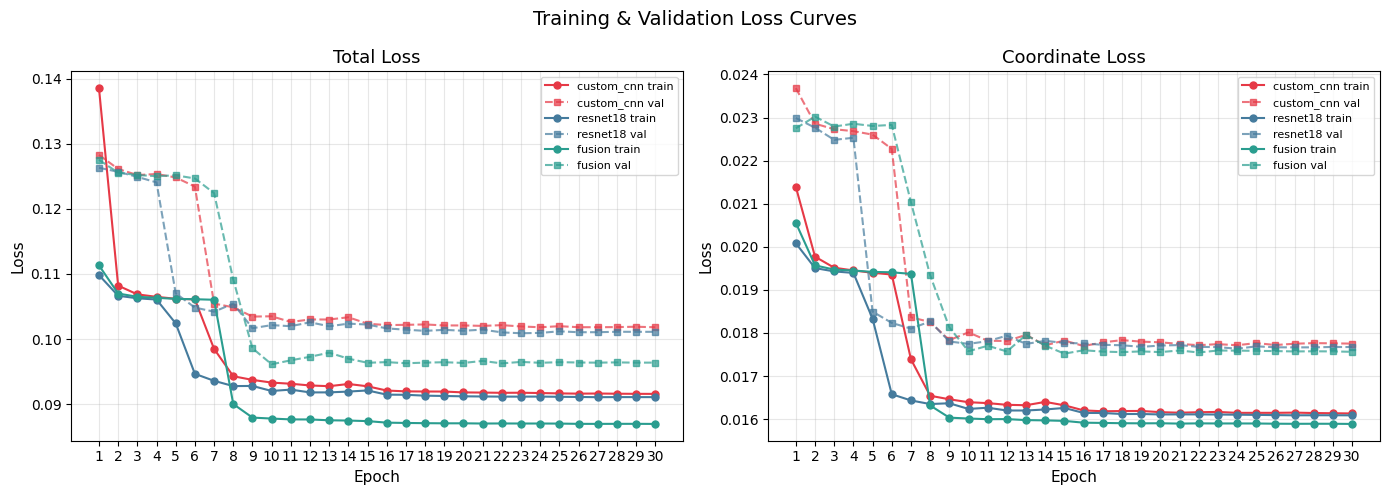

In [38]:
# ── STEP 7: Plot training & validation loss curves ──────────────────────────
# Requires: histories (populated by STEP 6)
plot_loss_curves(histories)


---
## 6. Evaluation Metrics

### 6.1 Metric Implementations

### 6.2 Full Evaluation on Test Set

In [39]:
# ════════════════════════════════════════════════════════════════════
#  EVALUATION METRICS
# ════════════════════════════════════════════════════════════════════

def compute_pck(pred_coords, gt_coords, visibility,
                img_h=None, img_w=None, threshold=None):
    """
    Percentage of Correct Keypoints (PCK@threshold).
    A keypoint is correct if its Euclidean distance to GT
    is within threshold * max(img_h, img_w) pixels.
    Returns (pck_overall, pck_per_kp array of shape (17,)).
    """
    img_h     = img_h     or cfg.IMG_H
    img_w     = img_w     or cfg.IMG_W
    threshold = threshold or cfg.PCK_THRESHOLD
    ref_dist  = threshold * max(img_h, img_w)

    pred_px = pred_coords.copy()
    gt_px   = gt_coords.copy()
    pred_px[:,:,0] *= img_w;  pred_px[:,:,1] *= img_h
    gt_px  [:,:,0] *= img_w;  gt_px  [:,:,1] *= img_h

    dist     = np.sqrt(((pred_px - gt_px) ** 2).sum(axis=-1))  # (N, 17)
    correct  = dist < ref_dist
    vis_mask = visibility > 0

    pck_per_kp = np.zeros(17)
    for k in range(17):
        m = vis_mask[:, k]
        if m.sum() > 0:
            pck_per_kp[k] = correct[:, k][m].mean()

    valid       = pck_per_kp > 0
    pck_overall = pck_per_kp[valid].mean() if valid.any() else 0.0
    return float(pck_overall), pck_per_kp


def compute_oks(pred_coords, gt_coords, visibility,
                sigmas=None, img_h=None, img_w=None):
    """
    Object Keypoint Similarity (OKS).
    Returns (mean_oks, per_sample_oks array of shape (N,)).
    """
    img_h  = img_h  or cfg.IMG_H
    img_w  = img_w  or cfg.IMG_W
    sigmas = sigmas if sigmas is not None else cfg.OKS_SIGMAS
    k2     = max(img_h, img_w) ** 2

    pred_px = pred_coords.copy()
    gt_px   = gt_coords.copy()
    pred_px[:,:,0] *= img_w;  pred_px[:,:,1] *= img_h
    gt_px  [:,:,0] *= img_w;  gt_px  [:,:,1] *= img_h

    d2       = ((pred_px - gt_px) ** 2).sum(axis=-1)          # (N, 17)
    s2       = (sigmas * 2) ** 2                                # (17,)
    oks_vals = np.exp(-d2 / (2 * s2[None] * k2))               # (N, 17)

    vis_mask       = (visibility > 0).astype(float)
    per_sample_oks = ((oks_vals * vis_mask).sum(1)
                      / vis_mask.sum(1).clip(min=1))
    return float(per_sample_oks.mean()), per_sample_oks


def compute_mae(pred_coords, gt_coords, visibility,
                img_h=None, img_w=None):
    """Mean Absolute Error in pixels (visible keypoints only)."""
    img_h = img_h or cfg.IMG_H
    img_w = img_w or cfg.IMG_W

    pred_px = pred_coords.copy()
    gt_px   = gt_coords.copy()
    pred_px[:,:,0] *= img_w;  pred_px[:,:,1] *= img_h
    gt_px  [:,:,0] *= img_w;  gt_px  [:,:,1] *= img_h

    diff = np.abs(pred_px - gt_px).sum(-1)   # (N, 17)
    vis  = visibility > 0
    return float(diff[vis].mean()) if vis.sum() > 0 else 0.0


def compute_f1_precision(pred_coords, gt_coords, visibility,
                         img_h=None, img_w=None, threshold=None):
    """
    F1-Score and Precision for keypoint detection.

    The model always produces a prediction for every keypoint slot.
    We therefore treat every slot as a detection attempt:
      - GT positive  : keypoint is annotated (visible > 0)
      - Pred positive: prediction is within the distance threshold
                       (regardless of visibility)
    This means a prediction outside threshold on a visible keypoint
    correctly counts as a False Positive, giving meaningful precision.

      TP: within threshold  AND  GT visible
      FP: outside threshold AND  GT visible   (wrong prediction)
      FN: within threshold  AND  GT invisible (predicted where nothing is)
          — or simply: visible keypoint not predicted within threshold
    """
    img_h     = img_h     or cfg.IMG_H
    img_w     = img_w     or cfg.IMG_W
    threshold = threshold or cfg.PCK_THRESHOLD
    ref_dist  = threshold * max(img_h, img_w)

    pred_px = pred_coords.copy()
    gt_px   = gt_coords.copy()
    pred_px[:,:,0] *= img_w;  pred_px[:,:,1] *= img_h
    gt_px  [:,:,0] *= img_w;  gt_px  [:,:,1] *= img_h

    dist    = np.sqrt(((pred_px - gt_px) ** 2).sum(-1))  # (N, 17)
    within  = (dist < ref_dist).flatten()                 # pred positive
    visible = (visibility > 0).flatten()                  # GT positive

    # y_true: 1 = GT has a keypoint here
    y_true = visible.astype(int)
    # y_pred: 1 = model predicted within threshold (irrespective of visibility)
    y_pred = within.astype(int)

    f1   = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    return float(f1), float(prec)


print("Evaluation metrics defined: compute_pck, compute_oks, compute_mae, "
      "compute_f1_precision.")


Evaluation metrics defined: compute_pck, compute_oks, compute_mae, compute_f1_precision.


In [40]:
@torch.no_grad()
def evaluate_model(model, loader, device, model_name='model'):
    """Evaluate a trained model on a DataLoader. Returns metrics dict."""
    model.eval()
    all_pred, all_gt, all_vis = [], [], []

    for batch in tqdm(loader, desc=f'  Eval {model_name}'):
        radar = batch['radar'].to(device)
        gt_kp = batch['coords'].cpu().numpy()
        vis   = batch['vis'].cpu().numpy()

        _, pred_kp = model(radar)
        all_pred.append(pred_kp.cpu().numpy())
        all_gt.append(gt_kp)
        all_vis.append(vis)

    pred_all = np.concatenate(all_pred, axis=0)
    gt_all   = np.concatenate(all_gt,   axis=0)
    vis_all  = np.concatenate(all_vis,  axis=0)

    pck, pck_per_kp = compute_pck(pred_all, gt_all, vis_all)
    oks, _          = compute_oks(pred_all, gt_all, vis_all)
    mae             = compute_mae(pred_all, gt_all, vis_all)
    f1, prec        = compute_f1_precision(pred_all, gt_all, vis_all)

    results = {'model': model_name, 'PCK@0.05': pck, 'OKS': oks,
               'MAE_px': mae, 'F1': f1, 'Precision': prec,
               'pck_per_kp': pck_per_kp}

    print(f"\n── {model_name} ──────────────────────────")
    print(f"  PCK@0.05  : {pck*100:.2f}%")
    print(f"  OKS       : {oks:.4f}")
    print(f"  MAE (px)  : {mae:.2f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    return results



In [41]:
# ── STEP 8: Load best checkpoints and evaluate on the test set ──────────────
eval_results = {}

for mname, ModelClass in [
    ('custom_cnn', lambda: CustomCNN(cfg.NUM_KEYPOINTS, in_channels=2)),
    ('resnet18',   lambda: ResNet18PoseModel(cfg.NUM_KEYPOINTS, in_channels=2)),
    ('fusion',     lambda: FusionModel(cfg.NUM_KEYPOINTS)),
]:
    print(f'\n--- Evaluating {mname} ---')
    mod = ModelClass()
    mod = load_checkpoint(mod, mname).to(DEVICE)
    eval_results[mname] = evaluate_model(mod, test_loader, DEVICE, mname)

print('\nEvaluation complete.')



--- Evaluating custom_cnn ---
Loaded ./checkpoints\custom_cnn_best.pth  (epoch 24, val_loss=0.1018)


  Eval custom_cnn: 100%|██████████| 338/338 [02:11<00:00,  2.56it/s]



── custom_cnn ──────────────────────────
  PCK@0.05  : 14.35%
  OKS       : 0.5808
  MAE (px)  : 96.95
  F1-Score  : 0.2114
  Precision : 1.0000

--- Evaluating resnet18 ---
Loaded ./checkpoints\resnet18_best.pth  (epoch 23, val_loss=0.1009)


  Eval resnet18: 100%|██████████| 338/338 [00:29<00:00, 11.62it/s]



── resnet18 ──────────────────────────
  PCK@0.05  : 15.93%
  OKS       : 0.5825
  MAE (px)  : 96.50
  F1-Score  : 0.2172
  Precision : 1.0000

--- Evaluating fusion ---
Loaded ./checkpoints\fusion_best.pth  (epoch 10, val_loss=0.0961)


  Eval fusion: 100%|██████████| 338/338 [00:36<00:00,  9.38it/s]


── fusion ──────────────────────────
  PCK@0.05  : 15.70%
  OKS       : 0.5899
  MAE (px)  : 94.60
  F1-Score  : 0.2434
  Precision : 1.0000

Evaluation complete.


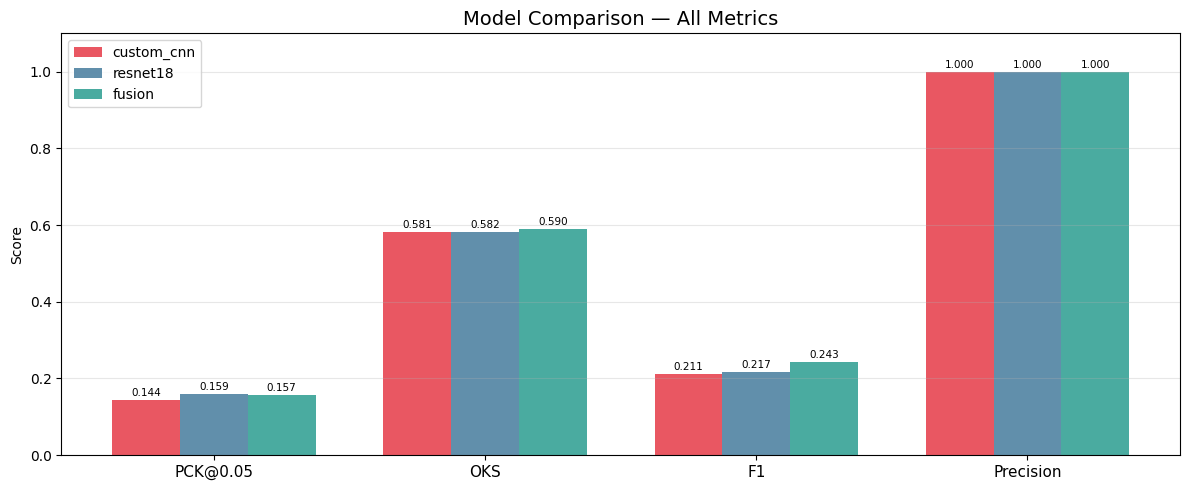

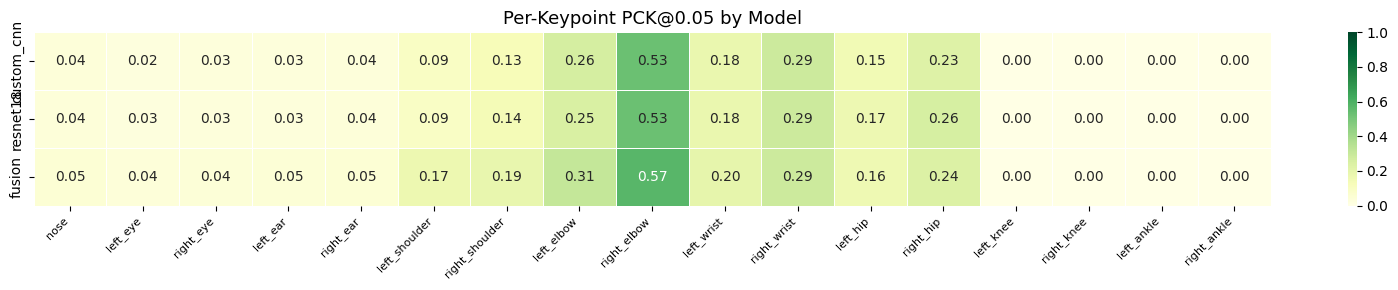

In [42]:
# ── STEP 9: Visualise model comparison metrics ──────────────────────────────
# Requires: eval_results (populated by STEP 8)
plot_model_comparison(eval_results)
plot_pck_per_keypoint(eval_results)


### 6.3 Adverse Condition Evaluation

In [43]:
class AdverseConditionDataset(Dataset):
    """
    Wraps MMVRDataset and applies fixed perturbations to radar heatmaps
    to simulate challenging sensing conditions:
        'noise'     — strong Gaussian noise on radar
        'dropout'   — randomly zero out 30% of radar pixels (occlusion proxy)
        'low_power' — scale radar signal to 20% (weak return / dark room proxy)
    """

    def __init__(self, base_dataset, condition='noise'):
        self.base      = base_dataset
        self.condition = condition

    def __len__(self):
        return len(self.base)

    def _apply(self, radar_tensor):
        t = radar_tensor.clone()
        if self.condition == 'noise':
            noise = torch.randn_like(t) * 0.15
            return torch.clamp(t + noise, 0.0, 1.0)
        elif self.condition == 'dropout':
            mask = (torch.rand_like(t) > 0.30).float()
            return t * mask
        elif self.condition == 'low_power':
            return t * 0.2
        return t

    def __getitem__(self, idx):
        sample = dict(self.base[idx])
        sample['radar'] = self._apply(sample['radar'])
        return sample


Loaded ./checkpoints\custom_cnn_best.pth  (epoch 24, val_loss=0.1018)


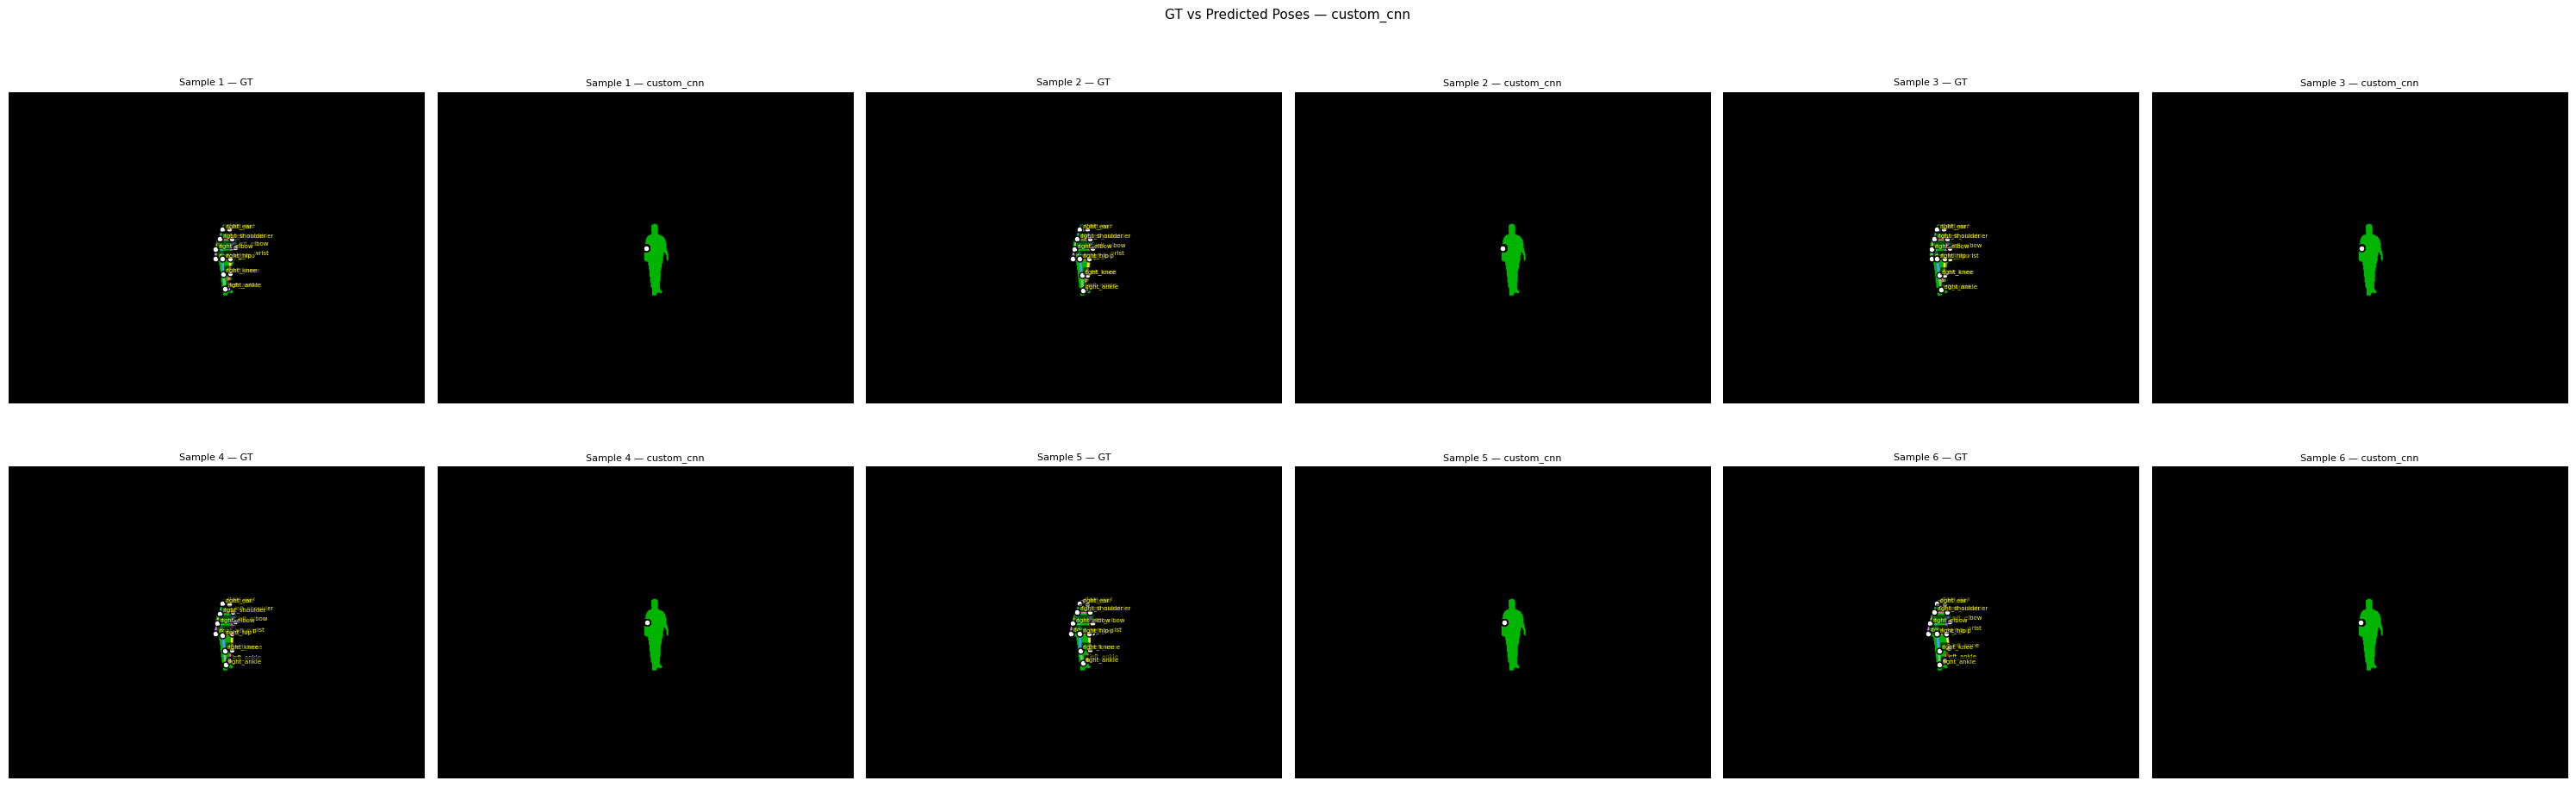

Saved: ./results/predictions_custom_cnn.png
Loaded ./checkpoints\resnet18_best.pth  (epoch 23, val_loss=0.1009)


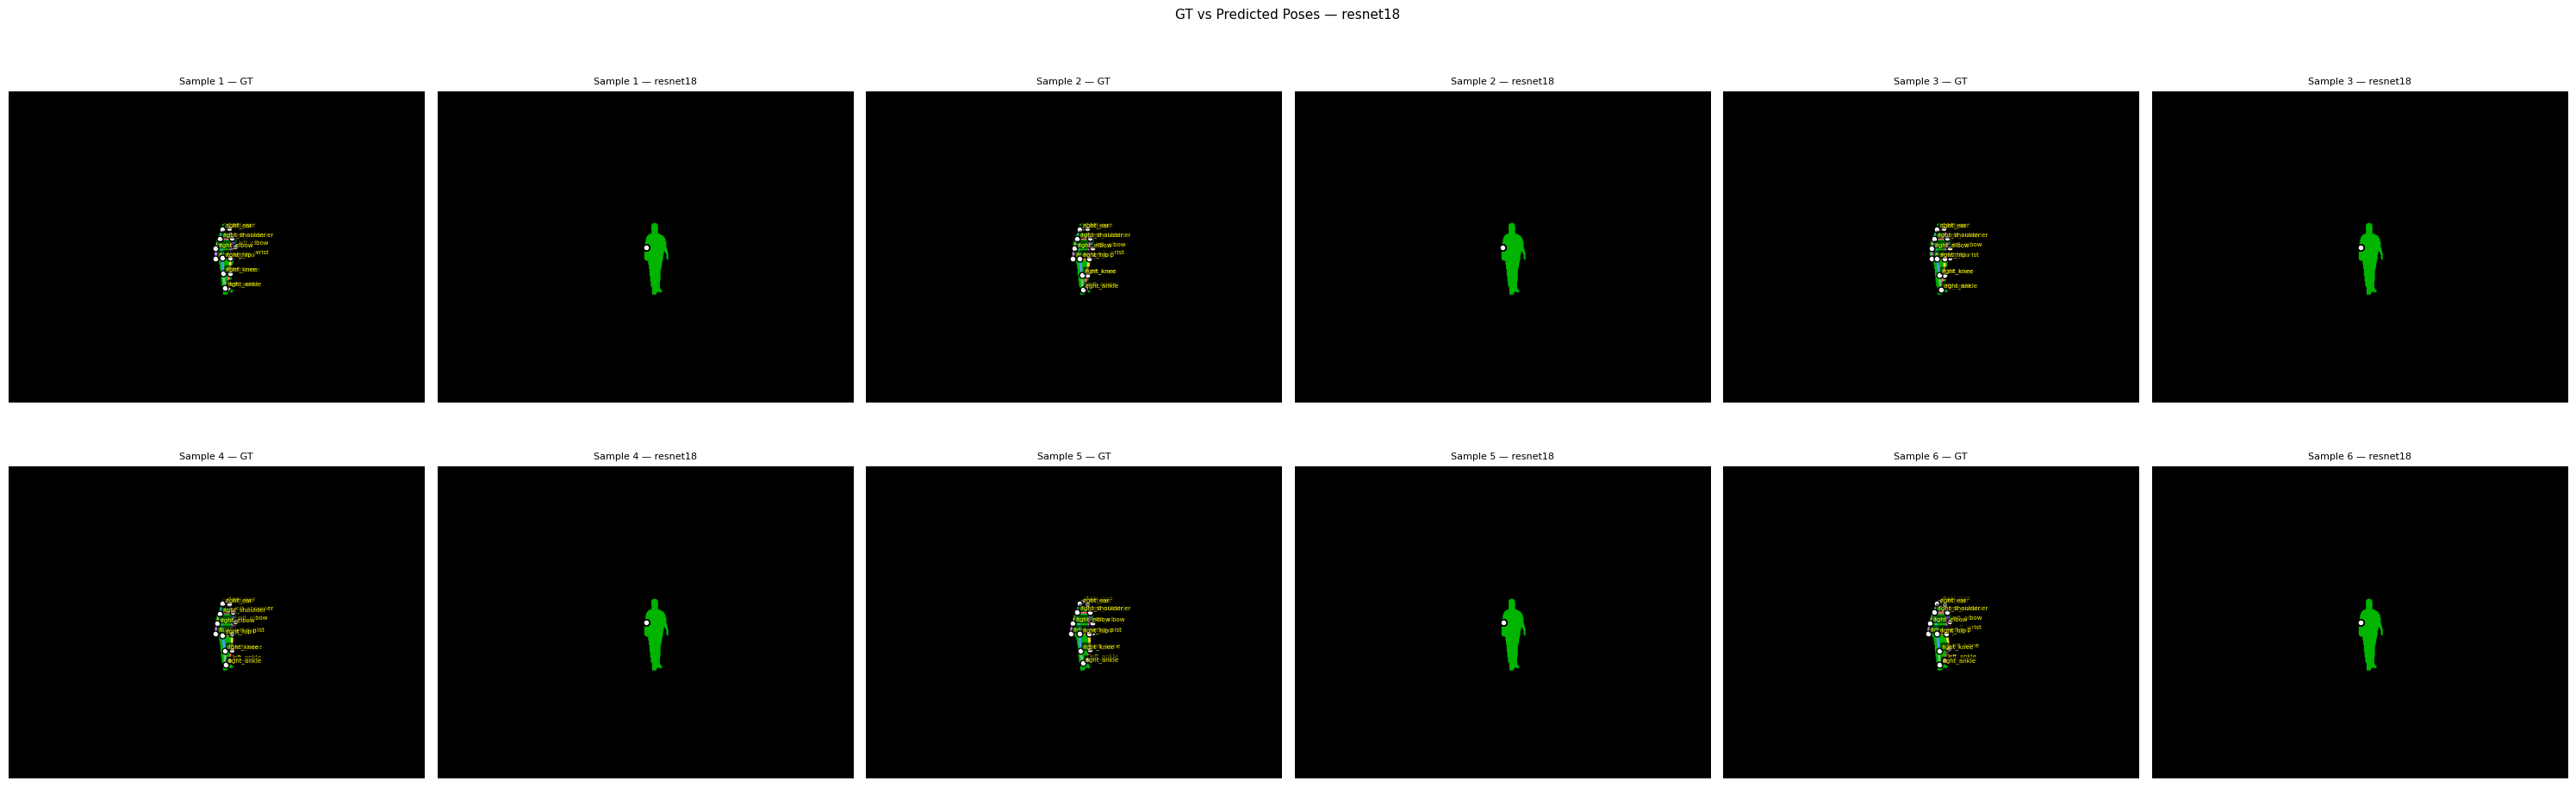

Saved: ./results/predictions_resnet18.png
Loaded ./checkpoints\fusion_best.pth  (epoch 10, val_loss=0.0961)


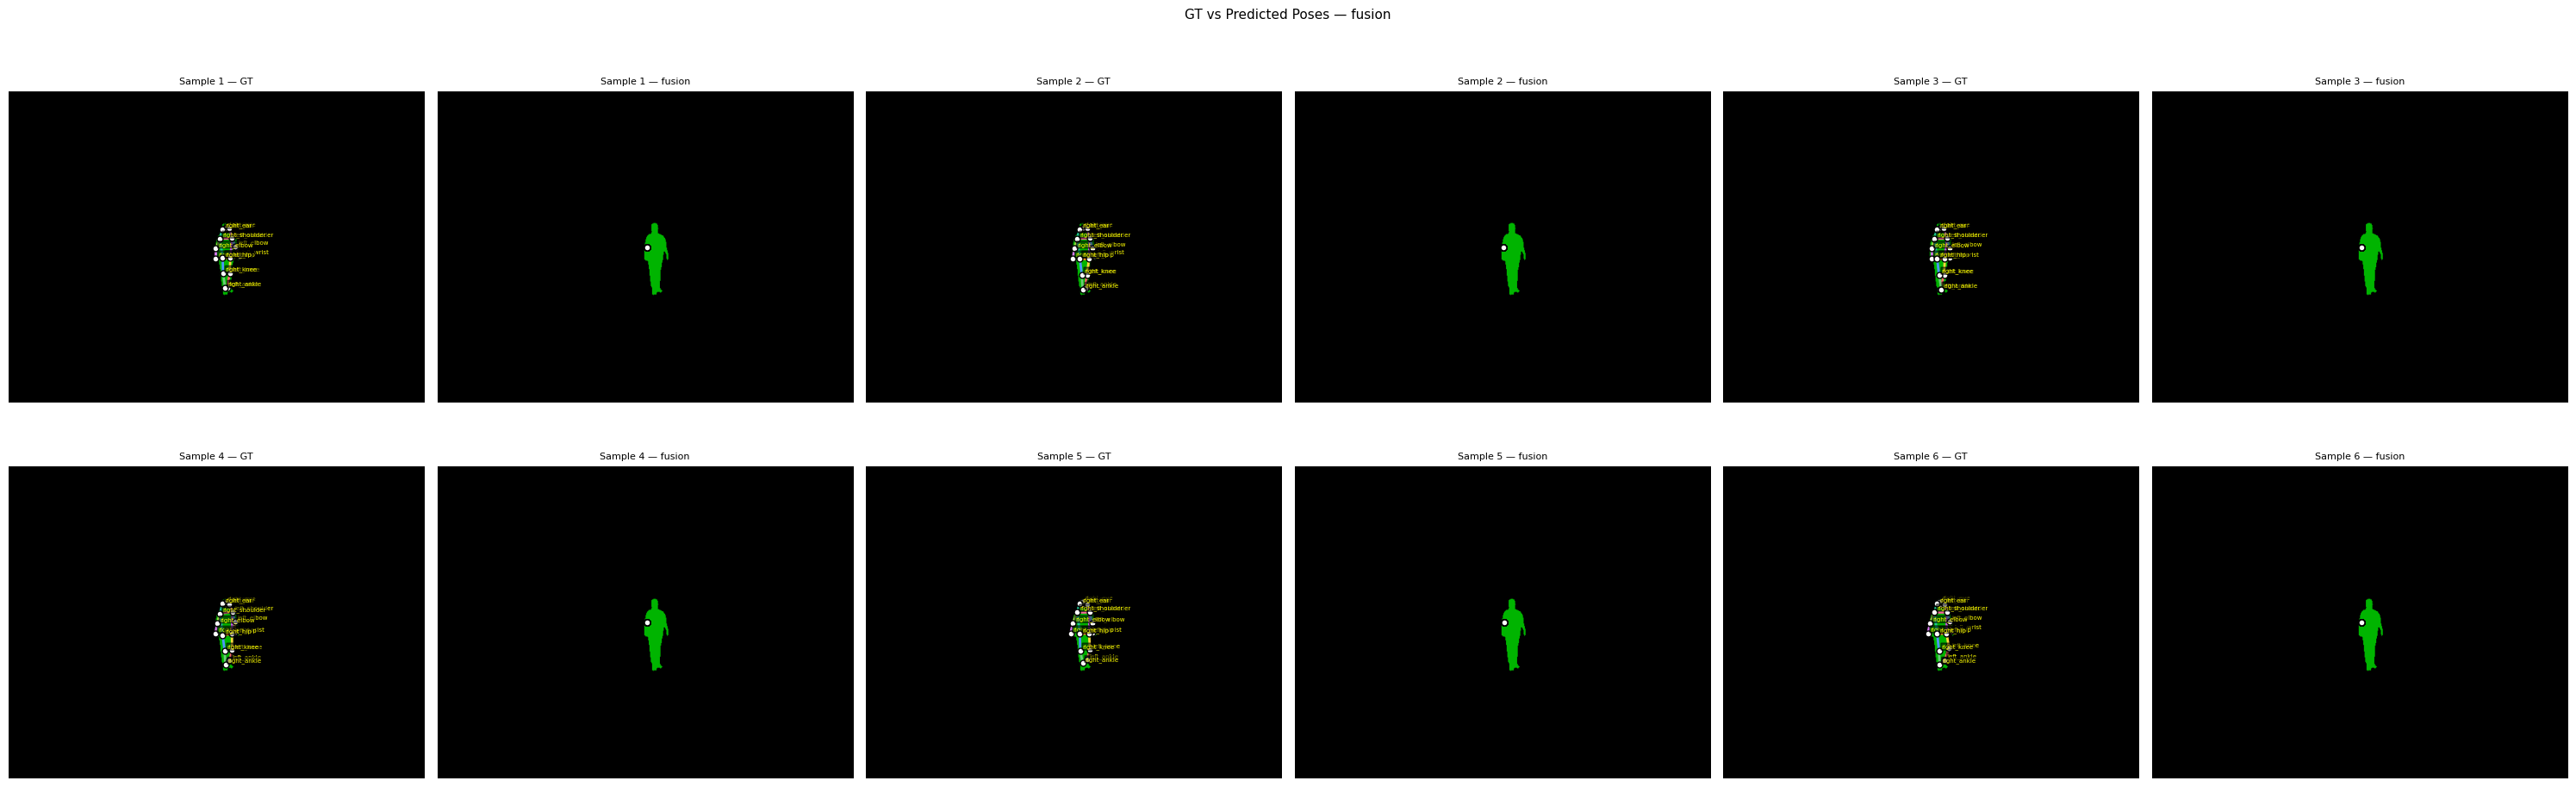

Saved: ./results/predictions_fusion.png


In [44]:
# ── STEP 10: Qualitative skeleton overlays (GT vs Predicted) ───────────────

@torch.no_grad()
def visualise_predictions_with_mask(model, loader, device, model_name,
                                     n_samples=6, save_dir=cfg.RESULTS_DIR):
    """
    Side-by-side GT vs prediction panels.
    coords[:,0] = x/col (width axis) → matplotlib X
    coords[:,1] = y/row (height axis) → matplotlib Y
    """
    model.eval()
    batch   = next(iter(loader))
    n       = min(n_samples, batch['radar'].shape[0])
    radar   = batch['radar'][:n].to(device)
    gt_kp   = batch['coords'][:n].numpy()   # (n, 17, 2) [x_norm, y_norm]
    vis     = batch['vis'][:n].numpy()

    _, pred_kp = model(radar)
    pred_kp = pred_kp.cpu().numpy()

    ds      = loader.dataset
    cols    = min(n, 3)
    rows    = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols*2, figsize=(5*cols*2, 5*rows))
    axes    = np.array(axes).reshape(rows, cols*2)

    bone_colours = ['#ff6b6b','#ffd93d','#6bcb77','#4d96ff',
                    '#ff922b','#cc5de8','#20c997','#f06595',
                    '#74c0fc','#a9e34b','#ffa94d','#da77f2']

    def draw(ax, kps, vis_arr, title, sample_idx, label_names=False):
        try:
            meta      = ds.samples[sample_idx]
            mask_path = meta['pose_path'].replace('_pose.npz','_mask.npz')
            masks     = np.load(mask_path)['mask']
            canvas    = np.zeros((cfg.IMG_H, cfg.IMG_W, 3), dtype=np.uint8)
            for pi, m in enumerate(masks):
                c = [(0,180,0),(0,120,255),(255,80,0)][pi%3]
                for ch, cv in enumerate(c): canvas[:,:,ch][m] = cv
        except Exception:
            canvas = np.zeros((cfg.IMG_H, cfg.IMG_W, 3), dtype=np.uint8)

        ax.imshow(canvas)
        # Draw bones — x=col, y=row
        for bi, (a, b) in enumerate(cfg.SKELETON):
            if vis_arr[a] > 0.1 and vis_arr[b] > 0.1:
                ax.plot(
                    [kps[a,0]*cfg.IMG_W, kps[b,0]*cfg.IMG_W],  # x=col
                    [kps[a,1]*cfg.IMG_H, kps[b,1]*cfg.IMG_H],  # y=row
                    '-', color=bone_colours[bi % len(bone_colours)], lw=2, zorder=2
                )
        # Draw keypoints
        for ki in range(17):
            if vis_arr[ki] > 0.1:
                cx = kps[ki,0] * cfg.IMG_W   # x=col → horizontal
                cy = kps[ki,1] * cfg.IMG_H   # y=row → vertical
                ax.plot(cx, cy, 'o', color='white', ms=5,
                        markeredgecolor='black', zorder=3)
                if label_names:
                    ax.text(cx+4, cy-4, cfg.KP_NAMES[ki],
                            fontsize=5, color='yellow',
                            bbox=dict(boxstyle='round,pad=0.1',
                                      fc='black', alpha=0.5))
        ax.set_xlim(0, cfg.IMG_W); ax.set_ylim(cfg.IMG_H, 0)  # row 0=top
        ax.set_title(title, fontsize=8); ax.axis('off')

    for i in range(n):
        r   = i // cols
        c   = (i %  cols) * 2
        draw(axes[r, c],   gt_kp[i],   vis[i],
             f'Sample {i+1} — GT', i, label_names=True)
        draw(axes[r, c+1], pred_kp[i], vis[i],
             f'Sample {i+1} — {model_name}', i)

    for i in range(n, rows*cols):
        r = i // cols
        axes[r,(i%cols)*2  ].axis('off')
        axes[r,(i%cols)*2+1].axis('off')

    plt.suptitle(f'GT vs Predicted Poses — {model_name}', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'predictions_{model_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_dir}/predictions_{model_name}.png")


for mname, ModelClass in [
    ('custom_cnn', lambda: CustomCNN(cfg.NUM_KEYPOINTS, in_channels=2)),
    ('resnet18',   lambda: ResNet18PoseModel(cfg.NUM_KEYPOINTS, in_channels=2)),
    ('fusion',     lambda: FusionModel(cfg.NUM_KEYPOINTS)),
]:
    mod = ModelClass()
    mod = load_checkpoint(mod, mname).to(DEVICE)
    visualise_predictions_with_mask(mod, test_loader, DEVICE, mname, n_samples=6)


In [45]:
# ── STEP 11: Radar heatmap overlay visualisation ────────────────────────────
def visualise_radar_overlay(loader, n=4, save_dir=cfg.RESULTS_DIR):
    """Show hori and vert radar heatmaps side by side with keypoints overlaid."""
    batch   = next(iter(loader))
    radar_t = batch['radar']
    coords  = batch['coords'].numpy()
    vis     = batch['vis'].numpy()

    fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))
    for i in range(n):
        hori = radar_t[i, 0].numpy()
        vert = radar_t[i, 1].numpy()

        axes[i,0].imshow(hori, cmap='plasma', aspect='auto')
        axes[i,0].set_title(f'Sample {i+1} — Horizontal heatmap', fontsize=9)
        axes[i,0].axis('off')

        axes[i,1].imshow(vert, cmap='plasma', aspect='auto')
        # overlay keypoints scaled to radar space
        for ki in range(17):
            if vis[i,ki] > 0.1:
                rx = coords[i,ki,0] * cfg.RADAR_W
                ry = coords[i,ki,1] * cfg.RADAR_H
                axes[i,1].plot(rx, ry, 'o', color='lime', ms=4)
        axes[i,1].set_title(f'Sample {i+1} — Vertical heatmap + KP', fontsize=9)
        axes[i,1].axis('off')

    plt.suptitle('Radar Heatmaps with Keypoint Overlay', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'radar_overlay.png'),
                dpi=150, bbox_inches='tight')
    plt.show()



In [46]:
# ── STEP 12: 3D pose reconstruction via PoseLiftingMLP ──────────────────────
fus_for_lift = FusionModel(cfg.NUM_KEYPOINTS)
fus_for_lift = load_checkpoint(fus_for_lift, 'fusion').to(DEVICE)
fus_for_lift.eval()

lifter_trained = PoseLiftingMLP(cfg.NUM_KEYPOINTS).to(DEVICE)
lift_optimizer = torch.optim.Adam(lifter_trained.parameters(), lr=1e-3)
lift_criterion = torch.nn.SmoothL1Loss()

print('Training PoseLiftingMLP (5 epochs) on frozen fusion encoder...')
for ep in range(5):
    lifter_trained.train(); ep_loss = 0.0
    for batch in tqdm(train_loader, desc=f'  Lifter ep {ep+1}', leave=False):
        radar = batch['radar'].to(DEVICE)
        gt_kp = batch['coords'].to(DEVICE)
        with torch.no_grad():
            _, pred_2d = fus_for_lift(radar)
        # Synthetic 3D GT: use 2D (x,y) + depth=0 as baseline
        gt_3d = torch.cat([gt_kp, torch.zeros_like(gt_kp[:,:,:1])], dim=-1)
        pred_3d = lifter_trained(pred_2d.detach(), radar)
        loss = lift_criterion(pred_3d, gt_3d)
        lift_optimizer.zero_grad(); loss.backward(); lift_optimizer.step()
        ep_loss += loss.item()
    print(f'  Epoch {ep+1}: loss = {ep_loss/len(train_loader):.4f}')



Loaded ./checkpoints\fusion_best.pth  (epoch 10, val_loss=0.0961)
Training PoseLiftingMLP (5 epochs) on frozen fusion encoder...


  Epoch 1: loss = 0.0053


  Epoch 2: loss = 0.0049


  Epoch 3: loss = 0.0049


  Epoch 4: loss = 0.0049


  Epoch 5: loss = 0.0049


Loaded ./checkpoints\fusion_best.pth  (epoch 10, val_loss=0.0961)

Evaluating under: noise


  Eval fusion_noise: 100%|██████████| 338/338 [00:39<00:00,  8.54it/s]



── fusion_noise ──────────────────────────
  PCK@0.05  : 10.13%
  OKS       : 0.5014
  MAE (px)  : 124.29
  F1-Score  : 0.1438
  Precision : 1.0000

Evaluating under: dropout


  Eval fusion_dropout: 100%|██████████| 338/338 [00:39<00:00,  8.58it/s]



── fusion_dropout ──────────────────────────
  PCK@0.05  : 15.59%
  OKS       : 0.5697
  MAE (px)  : 101.11
  F1-Score  : 0.2130
  Precision : 1.0000

Evaluating under: low_power


  Eval fusion_low_power: 100%|██████████| 338/338 [00:36<00:00,  9.31it/s]



── fusion_low_power ──────────────────────────
  PCK@0.05  : 14.05%
  OKS       : 0.5680
  MAE (px)  : 102.92
  F1-Score  : 0.2206
  Precision : 1.0000


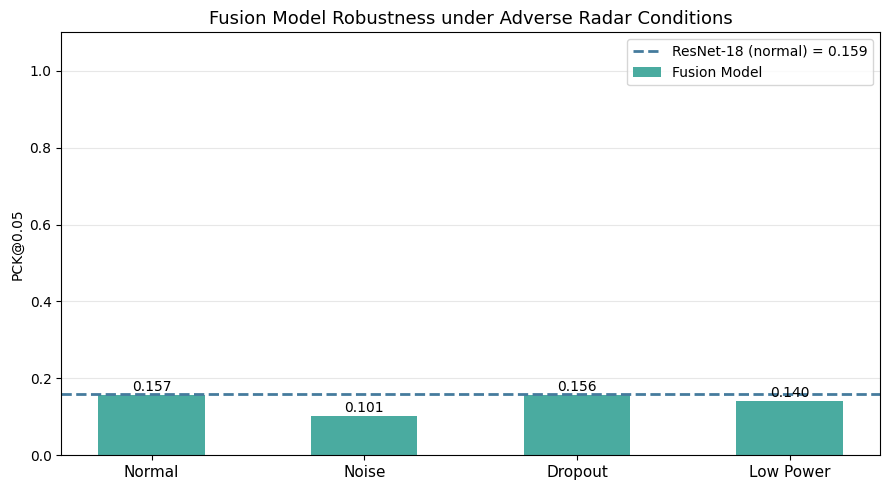

In [47]:
# ── STEP 13: Robustness evaluation under adverse radar conditions ────────────
fus_eval = FusionModel(cfg.NUM_KEYPOINTS)
fus_eval = load_checkpoint(fus_eval, 'fusion').to(DEVICE)

base_test_ds = test_loader.dataset
adverse = {}
for condition in ['noise', 'dropout', 'low_power']:
    print(f'\nEvaluating under: {condition}')
    adv_ds     = AdverseConditionDataset(base_test_ds, condition)
    adv_loader = DataLoader(adv_ds, batch_size=cfg.BATCH_SIZE,
                            shuffle=False, num_workers=0)   # 0 = no subprocess deadlock
    adverse[condition] = evaluate_model(fus_eval, adv_loader, DEVICE,
                                        f'fusion_{condition}')

plot_adverse_robustness(eval_results, adverse)


In [48]:
# ── STEP 14: Print final summary table ──────────────────────────────────────

print('\nAdverse Condition Results (Fusion Model — radar perturbations):')
print(f"{'Condition':<12} {'PCK@5%':>9} {'OKS':>9} {'MAE(px)':>9} {'F1':>9}")
print('-' * 50)
for cond, r in adverse.items():
    print(f"{cond:<12} "
          f"{r['PCK@0.05']*100:>8.2f}% "
          f"{r['OKS']:>9.4f} "
          f"{r['MAE_px']:>9.2f} "
          f"{r['F1']:>9.4f}")



Adverse Condition Results (Fusion Model — radar perturbations):
Condition       PCK@5%       OKS   MAE(px)        F1
--------------------------------------------------
noise           10.13%    0.5014    124.29    0.1438
dropout         15.59%    0.5697    101.11    0.2130
low_power       14.05%    0.5680    102.92    0.2206


---
## 9. Save Final Model

The best `.pth` checkpoints are automatically saved in `./checkpoints/` during training.
This cell packages them for submission.

In [49]:
import shutil

def export_final_models(cfg):
    """Copy best checkpoints into results dir for easy submission."""
    for mname in ['custom_cnn', 'resnet18', 'fusion']:
        src = os.path.join(cfg.CHECKPOINT_DIR, f'{mname}_best.pth')
        dst = os.path.join(cfg.RESULTS_DIR,    f'{mname}_final.pth')
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f"  Exported: {dst}")
        else:
            print(f"  [SKIP] {src} not found")

export_final_models(cfg)
print("\nAll done! Submission files:")
for f in os.listdir(cfg.RESULTS_DIR):
    print(f"  ./results/{f}")

  Exported: ./results\custom_cnn_final.pth
  Exported: ./results\resnet18_final.pth
  Exported: ./results\fusion_final.pth

All done! Submission files:
  ./results/adverse_robustness.png
  ./results/custom_cnn_final.pth
  ./results/eval_results.json
  ./results/fusion_final.pth
  ./results/histories.json
  ./results/histories1.json
  ./results/loss_curves.png
  ./results/model_comparison.png
  ./results/pck_per_keypoint.png
  ./results/predictions_custom_cnn.png
  ./results/predictions_fusion.png
  ./results/predictions_resnet18.png
  ./results/resnet18_final.pth
  ./results/sample_visualisation.png


In [50]:
# ── STEP 15: Export final model checkpoints ─────────────────────────────────
import shutil
export_final_models(cfg)
print('\nFinal output files:')
for f in sorted(os.listdir(cfg.RESULTS_DIR)):
    size = os.path.getsize(os.path.join(cfg.RESULTS_DIR, f))
    print(f'  ./results/{f}  ({size/1024:.1f} KB)')


  Exported: ./results\custom_cnn_final.pth
  Exported: ./results\resnet18_final.pth
  Exported: ./results\fusion_final.pth

Final output files:
  ./results/adverse_robustness.png  (47.7 KB)
  ./results/custom_cnn_final.pth  (20916.5 KB)
  ./results/eval_results.json  (0.0 KB)
  ./results/fusion_final.pth  (28964.5 KB)
  ./results/histories.json  (15.5 KB)
  ./results/histories1.json  (15.5 KB)
  ./results/loss_curves.png  (197.1 KB)
  ./results/model_comparison.png  (45.4 KB)
  ./results/pck_per_keypoint.png  (99.6 KB)
  ./results/predictions_custom_cnn.png  (119.5 KB)
  ./results/predictions_fusion.png  (115.6 KB)
  ./results/predictions_resnet18.png  (117.9 KB)
  ./results/resnet18_final.pth  (37010.6 KB)
  ./results/sample_visualisation.png  (713.5 KB)


---
## Appendix: Architecture Diagram

```
                ┌──────────────┐     ┌─────────────────┐
   RGB Frame    │  RGB Encoder │     │  Radar Encoder   │  mmWave (hori+vert)
  (3,256,256) → │  (Res+CBAM)  │     │  (Res+CBAM)      │ ← (2,64,64)
                └──────┬───────┘     └────────┬─────────┘
                       │   (B,256,16,16)       │ (B,256,16,16)
                       └──────────┬────────────┘
                             Concat (B,512)
                                  │
                             1×1 Fusion
                                  │ (B,256,16,16)
                          ┌───────┴────────┐
                          │    Decoder     │
                          │  (DeConv ×2)  │
                          └───────┬────────┘
                                  │ (B,64,64,64)
                              1×1 Head
                                  │ (B,17,64,64)
                           SoftArgmax2D
                                  │
                           (B,17,2) x,y coords
                                  │
                        PoseLiftingMLP + radar depth
                                  │
                           (B,17,3) 3D coords
```